In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "configs").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import yaml
import pandas as pd
import numpy as np

import torch
from model import LightningWBoson
from physics.torchBoost import Booster as TorchBooster
from train import original as train

from matplotlib import pyplot as plt
from notebooks.plottingtool import plot_1d_hist, plot_2d_hist, plot_2d_res_hist

import mplhep as hep
hep.style.use("ATLAS")


In [2]:
CONFIG_PATH = REPO_ROOT / "configs/config.yaml"
# CONFIG_PATH = REPO_ROOT / "configs/config_no_w_mmd.yaml"
with CONFIG_PATH.open() as file:
    cfg = yaml.safe_load(file)

# Visualize the original training output, not scan-generated run directories.
RUN_DIR = Path(cfg["paths"]["saved_path"]).expanduser()
if not RUN_DIR.is_absolute():
    RUN_DIR = (Path.cwd() / RUN_DIR).resolve()

ckpt_files = sorted(
    (RUN_DIR / "logs" / "version_0" / "checkpoints").glob("*.ckpt"),
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)
print(f"Original training run directory: {RUN_DIR}")
print(f"Found checkpoint files: {[str(path) for path in ckpt_files]}")
if not ckpt_files:
    raise FileNotFoundError(f"No checkpoint files found under {RUN_DIR}")

ckpt_path = ckpt_files[0]
print(f"Using checkpoint: {ckpt_path}")


Original training run directory: /root/work/ww-pcres/hww_pcres_regressor_nofold
Found checkpoint files: ['/root/work/ww-pcres/hww_pcres_regressor_nofold/logs/version_0/checkpoints/reg-epoch=414-val_loss=19.96.ckpt']
Using checkpoint: /root/work/ww-pcres/hww_pcres_regressor_nofold/logs/version_0/checkpoints/reg-epoch=414-val_loss=19.96.ckpt


In [3]:
# Retrieve the same data split definition used by the original training config.
dm = train.main(train=False, config_path=str(CONFIG_PATH))
dm.setup(stage="test")
test_loader = dm.test_dataloader()

model = LightningWBoson.load_from_checkpoint(str(ckpt_path), weights_only=False, strict=False)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

feature_batches = []
prediction_batches = []
target_batches = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)

        feature_batches.append(inputs.cpu().numpy())
        prediction_batches.append(outputs.cpu().numpy())
        target_batches.append(targets.cpu().numpy())

train_features = np.concatenate(feature_batches, axis=0)
predictions = np.concatenate(prediction_batches, axis=0)
true_labels = np.concatenate(target_batches, axis=0)
print(f"Evaluated {len(predictions)} test events on {device}.")


Seed set to 114


Evaluation mode, loading checkpoints...
Using original pre-split HDF5 data
Train categories: ggF_train
Validation categories: ggF_val
Test categories: ggF_test
Using HDF5 categories: ggF_train
Training objects shape: (263735, 18)
Target objects shape: (263735, 10)
Removed 0 rows with NaN or infinite values
Using HDF5 categories: ggF_val
Training objects shape: (75569, 18)
Target objects shape: (75569, 10)
Removed 0 rows with NaN or infinite values
Using HDF5 categories: ggF_test
Training objects shape: (37681, 18)
Target objects shape: (37681, 10)
Removed 0 rows with NaN or infinite values
Using 10 workers in data loading.
Using pre-split dataset (train / val / test arrays)
Train split: 263735 samples
Validation split: 75569 samples
Test split: 37681 samples
Feature dims: train=(18,), val=(18,), test=(18,)
Target dims: train=(10,), val=(10,), test=(10,)
Loading model from checkpoint for evaluation... return datamodule
Using pre-split dataset (train / val / test arrays)
Train split: 263

In [4]:
true_lep0_px = train_features[:, 0]
true_lep0_py = train_features[:, 1]
true_lep0_pz = train_features[:, 2]
true_lep0_energy = train_features[:, 3]
true_lep1_px = train_features[:, 4]
true_lep1_py = train_features[:, 5]
true_lep1_pz = train_features[:, 6]
true_lep1_energy = train_features[:, 7]
true_met_px = train_features[:, 16]
true_met_py = train_features[:, 17]


In [5]:
pred_w0_px = predictions[..., 0]
pred_w0_py = predictions[..., 1]
pred_w0_pz = predictions[..., 2]
pred_w0_energy = np.exp(predictions[..., 3])
pred_w1_px = predictions[..., 4]
pred_w1_py = predictions[..., 5]
pred_w1_pz = predictions[..., 6]
pred_w1_energy = np.exp(predictions[..., 7])
pred_w0_mass_2 = pred_w0_energy**2 - (pred_w0_px**2 + pred_w0_py**2 + pred_w0_pz**2)
pred_w1_mass_2 = pred_w1_energy**2 - (pred_w1_px**2 + pred_w1_py**2 + pred_w1_pz**2)

true_w0_px = true_labels[..., 0]
true_w0_py = true_labels[..., 1]
true_w0_pz = true_labels[..., 2]
true_w0_energy = np.exp(true_labels[..., 3])
true_w1_px = true_labels[..., 4]
true_w1_py = true_labels[..., 5]
true_w1_pz = true_labels[..., 6]
true_w1_energy = np.exp(true_labels[..., 7])
true_w0_mass_2 = true_labels[..., 8] ** 2
true_w1_mass_2 = true_labels[..., 9] ** 2

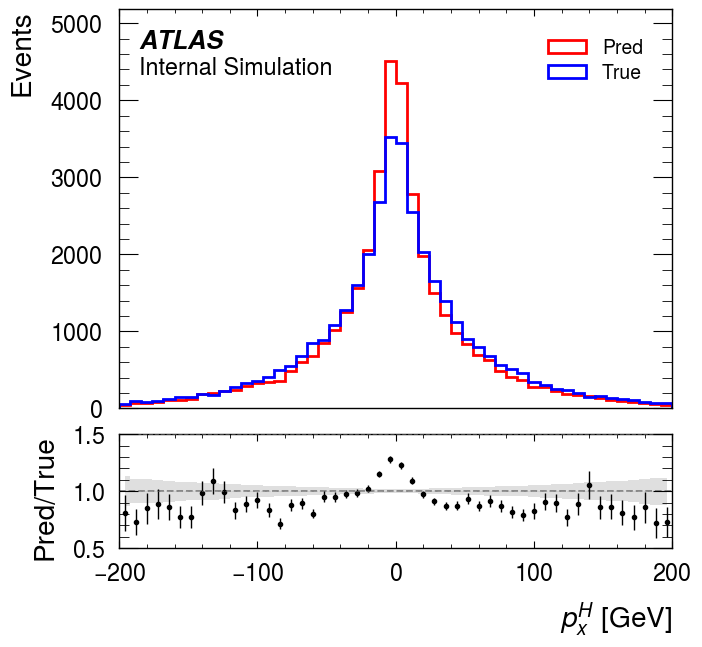

Rel err < 20%: 30.34 %


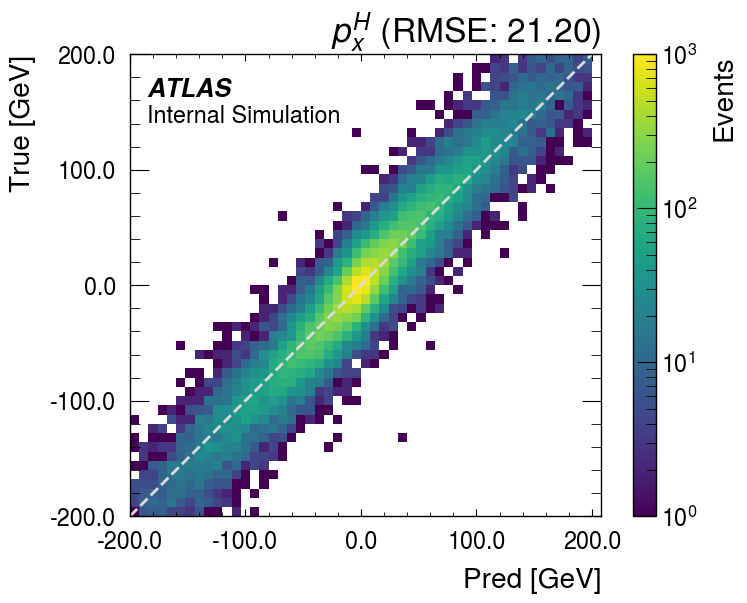

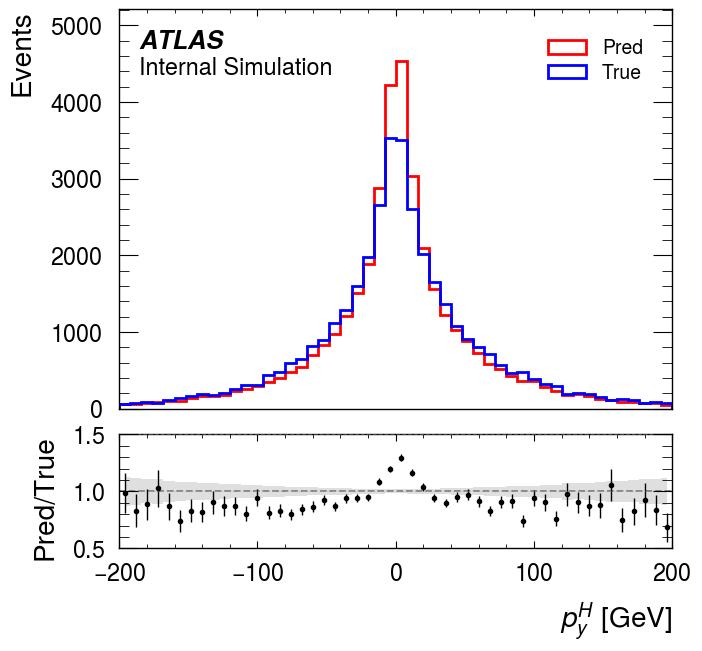

Rel err < 20%: 30.34 %


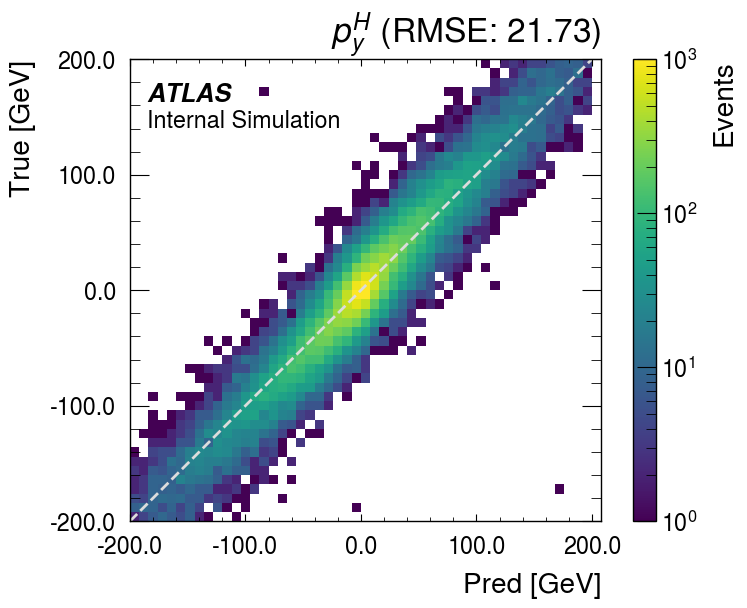

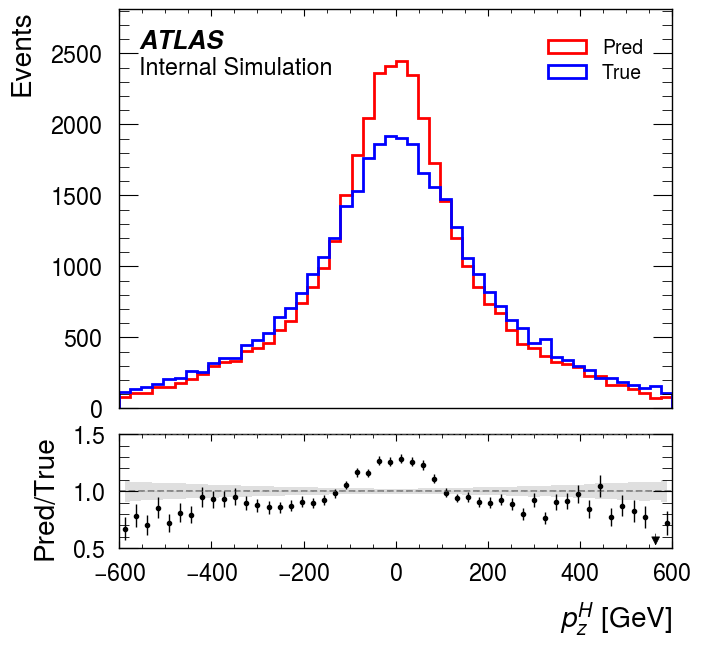

Rel err < 20%: 31.90 %


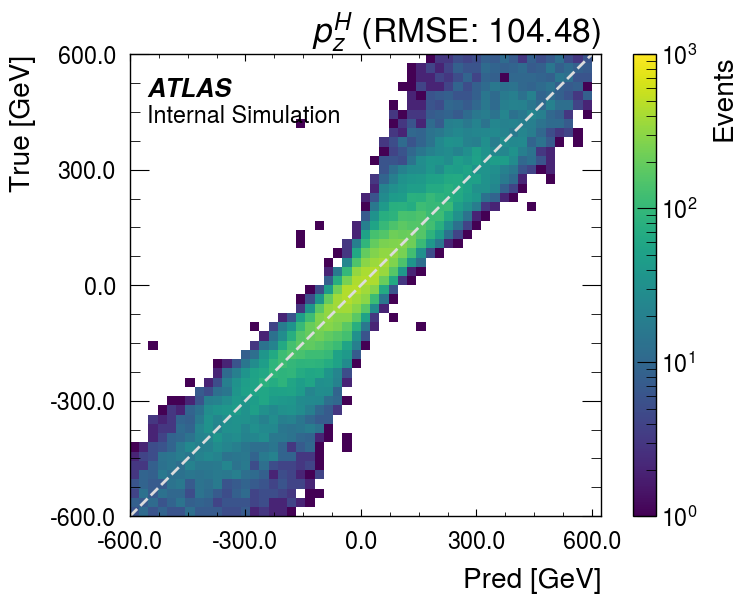

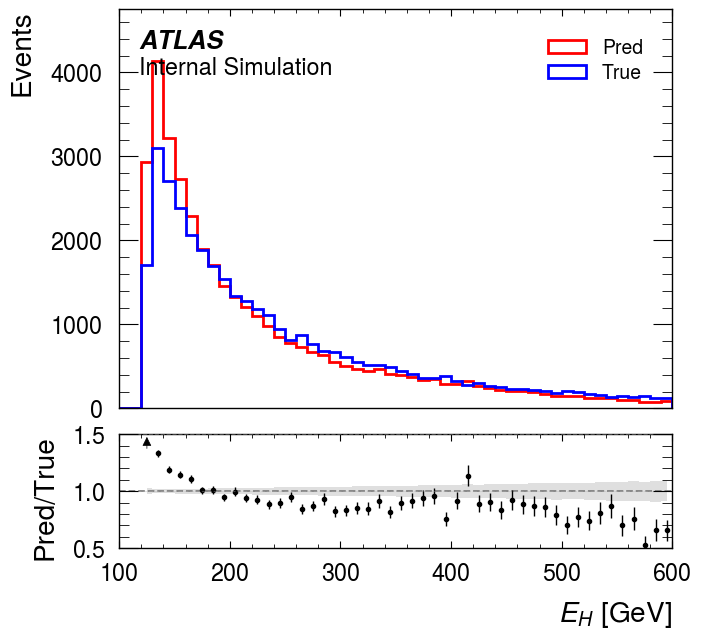

Rel err < 20%: 73.18 %


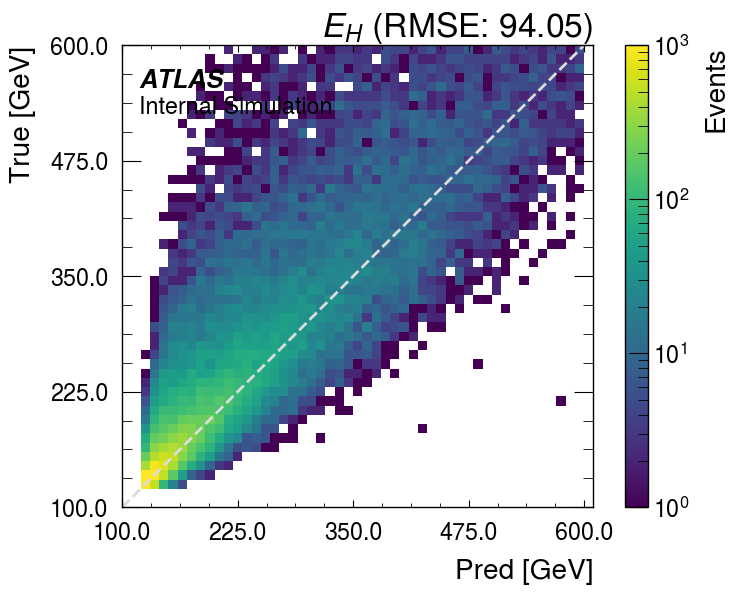

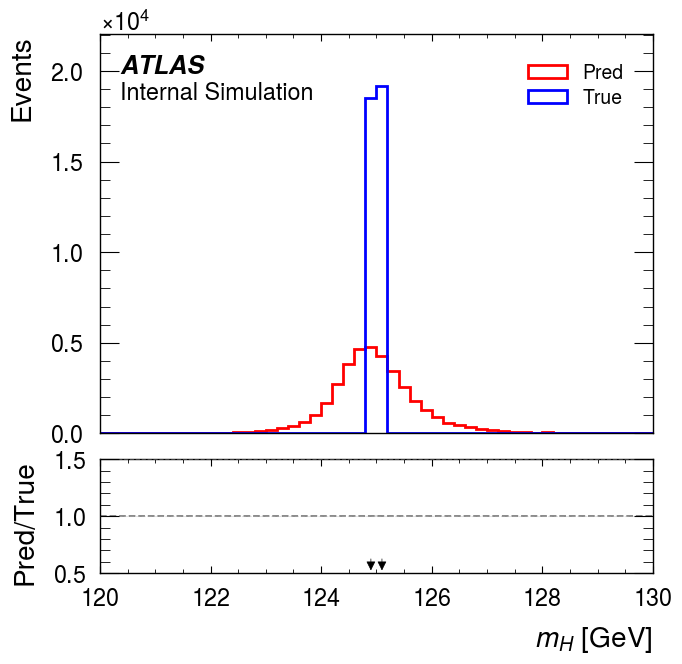

Mean predicted Higgs mass: 125.04 GeV, Std: 3.88 GeV
Rel err < 20%: 99.93 %


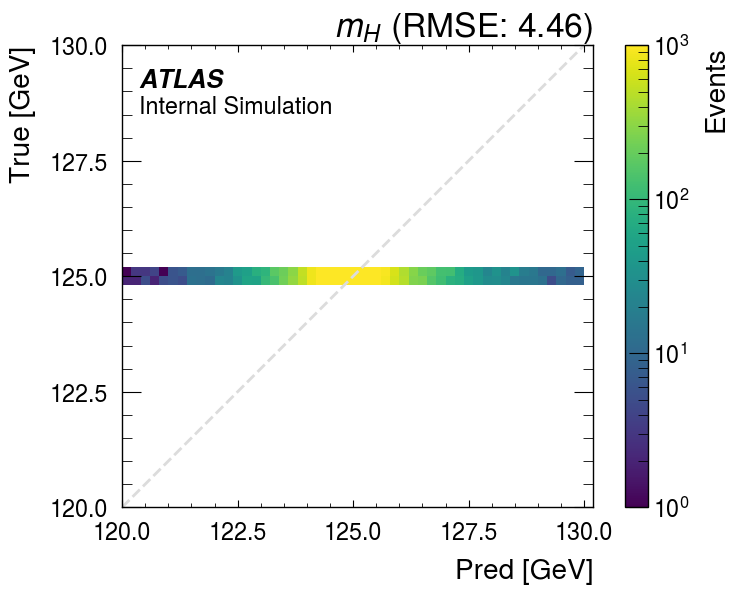

In [6]:
def safe_mass(mass2):
    return np.sqrt(np.clip(mass2, 0.0, None))

pred_higgs_px = pred_w0_px + pred_w1_px
pred_higgs_py = pred_w0_py + pred_w1_py
pred_higgs_pz = pred_w0_pz + pred_w1_pz
pred_higgs_energy = pred_w0_energy + pred_w1_energy
pred_higgs_mass_2 = pred_higgs_energy**2 - (pred_higgs_px**2 + pred_higgs_py**2 + pred_higgs_pz**2)
pred_higgs_mass = safe_mass(pred_higgs_mass_2)

true_higgs_px = true_w0_px + true_w1_px
true_higgs_py = true_w0_py + true_w1_py
true_higgs_pz = true_w0_pz + true_w1_pz
true_higgs_energy = true_w0_energy + true_w1_energy
true_higgs_mass_2 = true_higgs_energy**2 - (true_higgs_px**2 + true_higgs_py**2 + true_higgs_pz**2)
true_higgs_mass = safe_mass(true_higgs_mass_2)

plot_1d_hist(pred_higgs_px, true_higgs_px, "$p_x^{H}$", bins_edges=np.linspace(-200, 200, 51), unit="GeV")
plot_2d_hist(pred_higgs_px, true_higgs_px, "$p_x^{H}$", bins_edges=np.linspace(-200, 200, 51), log=True, unit="GeV", vmax=1000)
plot_1d_hist(pred_higgs_py, true_higgs_py, "$p_y^{H}$", bins_edges=np.linspace(-200, 200, 51), unit="GeV")
plot_2d_hist(pred_higgs_py, true_higgs_py, "$p_y^{H}$", bins_edges=np.linspace(-200, 200, 51), log=True, unit="GeV", vmax=1000)
plot_1d_hist(pred_higgs_pz, true_higgs_pz, "$p_z^{H}$", bins_edges=np.linspace(-600, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_pz, true_higgs_pz, "$p_z^{H}$", bins_edges=np.linspace(-600, 600, 51), log=True, unit="GeV", vmax=1000)
plot_1d_hist(pred_higgs_energy, true_higgs_energy, "$E_H$", bins_edges=np.linspace(100, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_energy, true_higgs_energy, "$E_H$", bins_edges=np.linspace(100, 600, 51), log=True, unit="GeV", vmax=1000)
plot_1d_hist(pred_higgs_mass, true_higgs_mass, "$m_H$", bins_edges=np.linspace(120, 130, 51), unit="GeV")
print(f"Mean predicted Higgs mass: {pred_higgs_mass.mean():.2f} GeV, Std: {pred_higgs_mass.std():.2f} GeV")
plot_2d_hist(pred_higgs_mass, true_higgs_mass, "$m_H$", bins_edges=np.linspace(120, 130, 51), log=True, unit="GeV", vmax=1000)


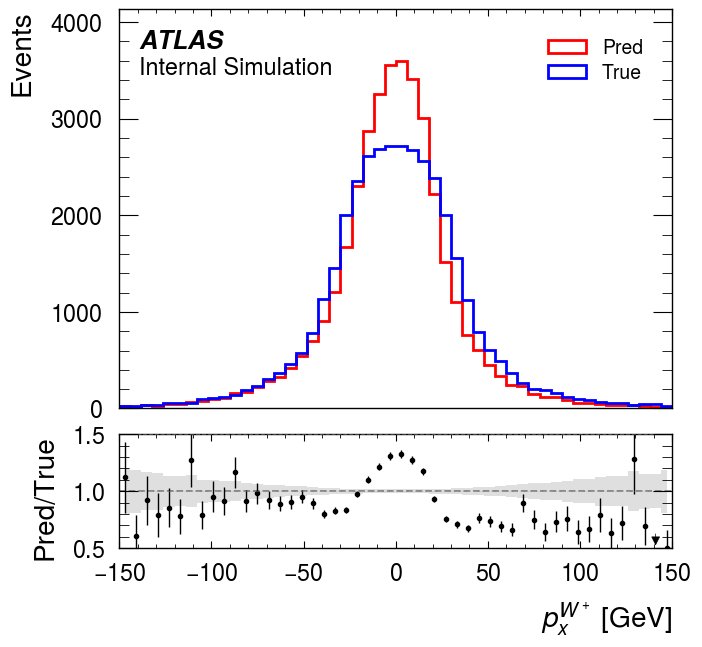

Rel err < 20%: 23.81 %


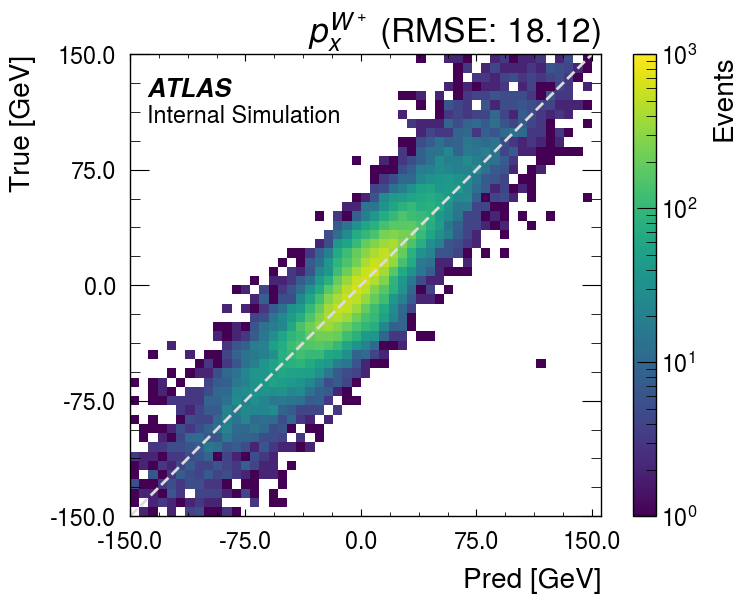

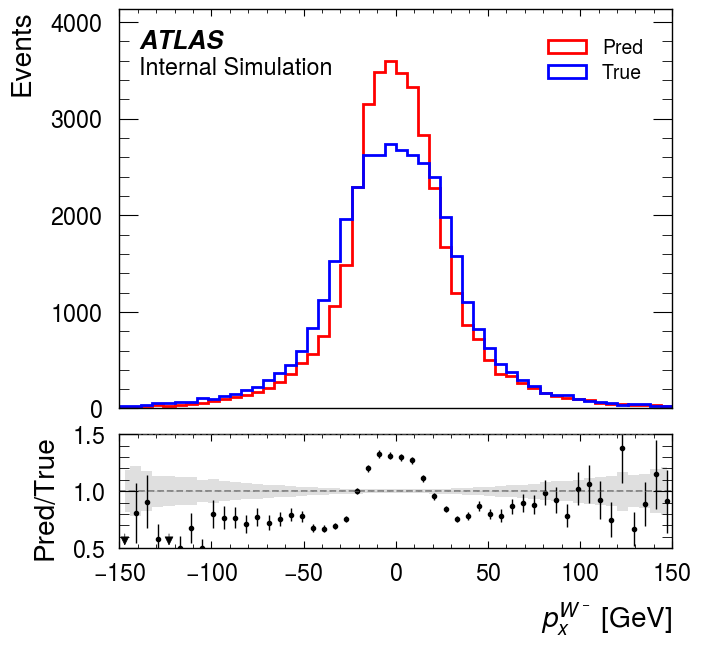

Rel err < 20%: 24.85 %


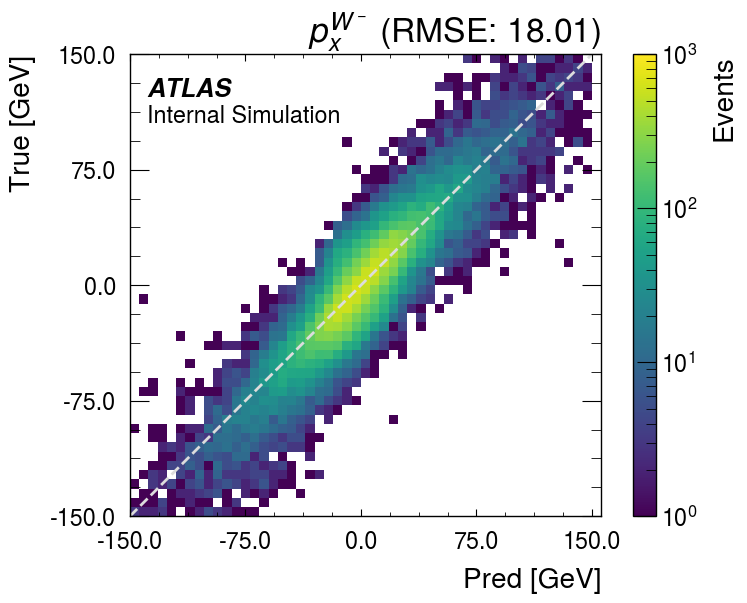

In [7]:
bins = np.linspace(-150, 150, 51)
plot_1d_hist(pred_w0_px, true_w0_px, bins_edges=bins, name=r"$p_x^{W^+}$")
plot_2d_hist(pred_w0_px, true_w0_px, name=r"$p_x^{W^+}$", bins_edges=bins, log=True, vmax=1000)
plot_1d_hist(pred_w1_px, true_w1_px, bins_edges=bins, name=r"$p_x^{W^-}$")
plot_2d_hist(pred_w1_px, true_w1_px, name=r"$p_x^{W^-}$", bins_edges=bins, log=True, vmax=1000)

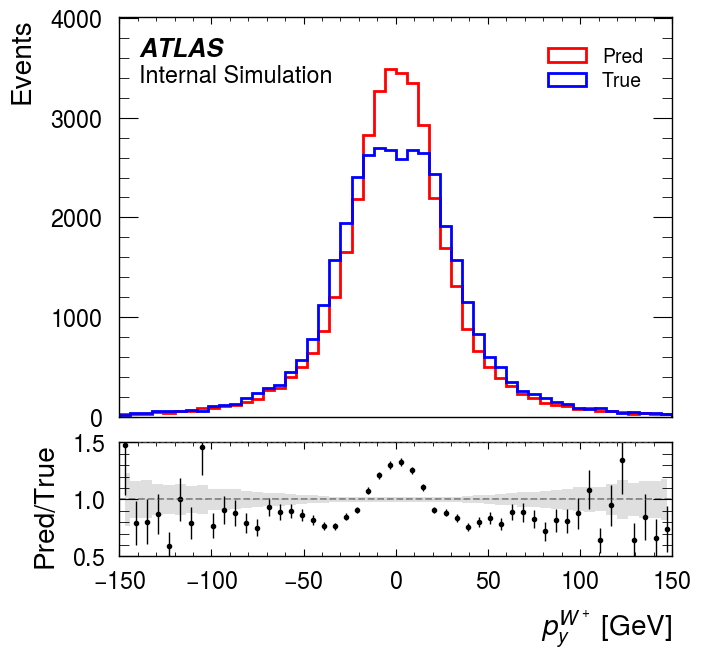

Rel err < 20%: 25.26 %


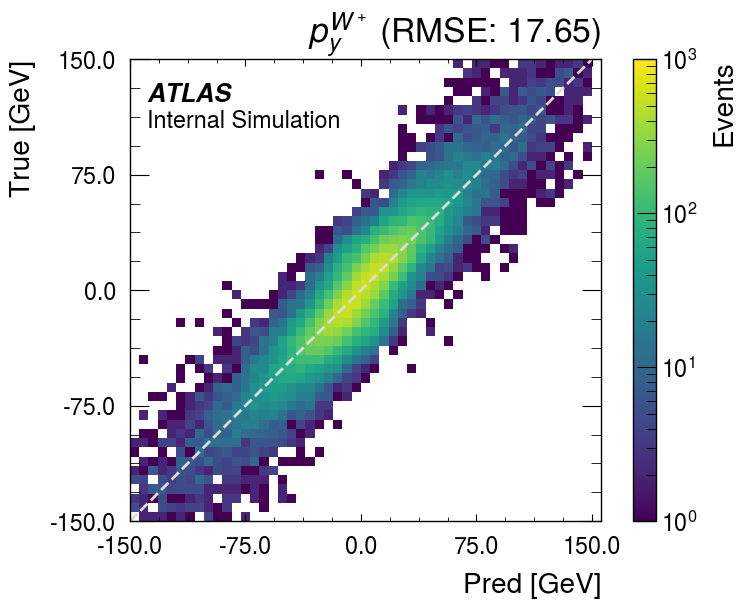

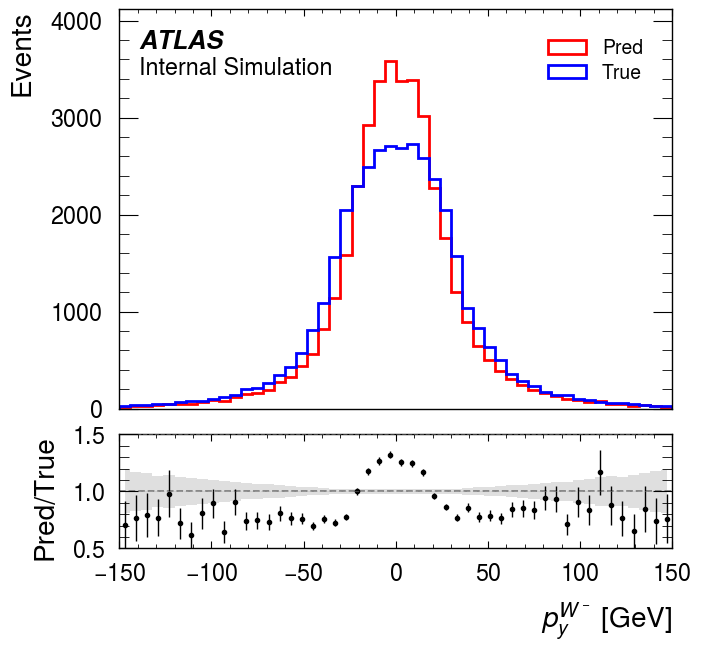

Rel err < 20%: 25.11 %


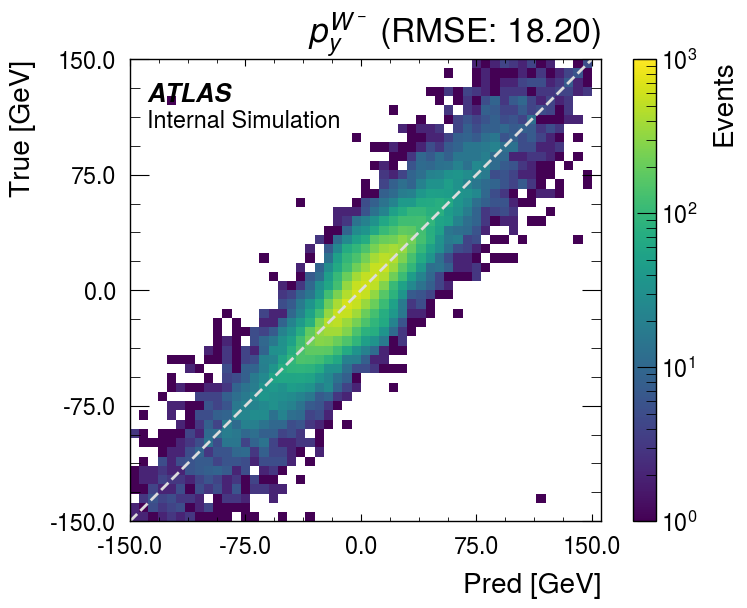

In [8]:
bins = np.linspace(-150, 150, 51)
plot_1d_hist(pred_w0_py, true_w0_py, bins_edges=bins, name=r"$p_y^{W^+}$")
plot_2d_hist(pred_w0_py, true_w0_py, name=r"$p_y^{W^+}$", bins_edges=bins, log=True, vmax=1000)
plot_1d_hist(pred_w1_py, true_w1_py, bins_edges=bins, name=r"$p_y^{W^-}$")
plot_2d_hist(pred_w1_py, true_w1_py, name=r"$p_y^{W^-}$", bins_edges=bins, log=True, vmax=1000)

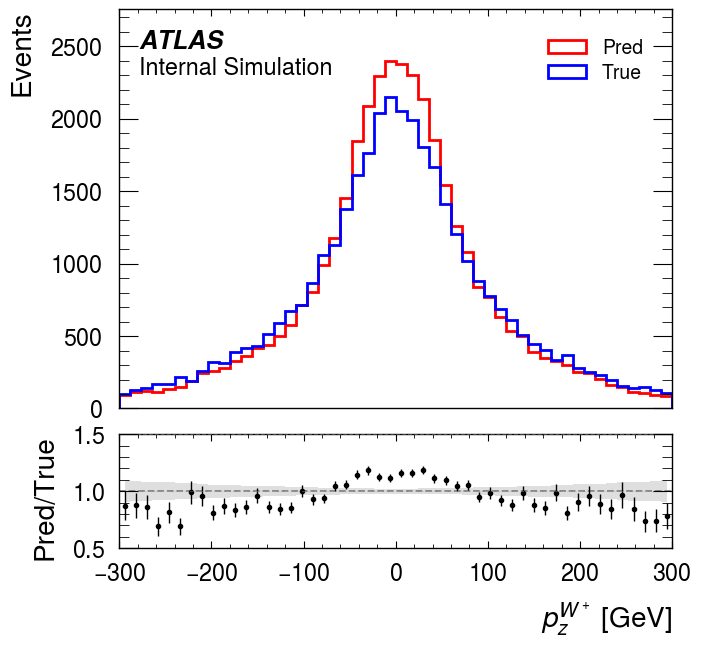

Rel err < 20%: 28.52 %


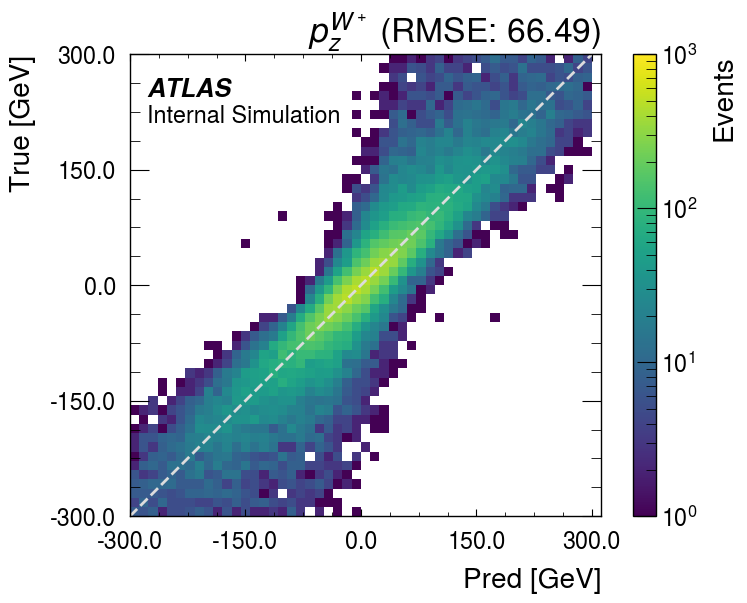

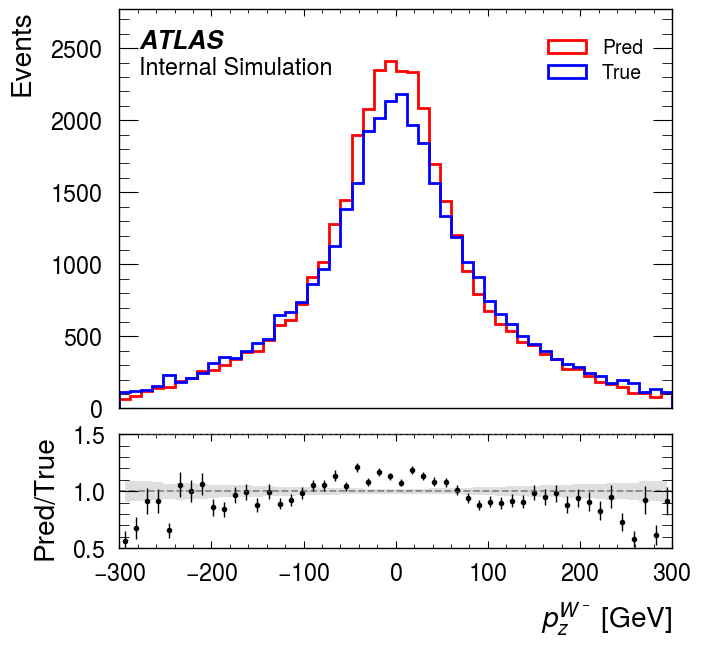

Rel err < 20%: 28.56 %


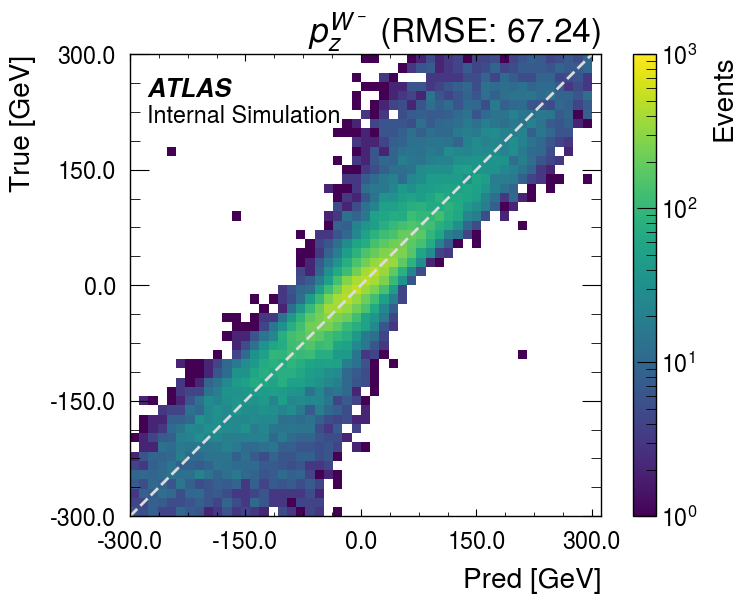

In [9]:
bins = np.linspace(-300, 300, 51)
plot_1d_hist(pred_w0_pz, true_w0_pz, bins_edges=bins, name=r"$p_z^{W^+}$")
plot_2d_hist(pred_w0_pz, true_w0_pz, name=r"$p_z^{W^+}$", bins_edges=bins, log=True, vmax=1000)
plot_1d_hist(pred_w1_pz, true_w1_pz, bins_edges=bins, name=r"$p_z^{W^-}$")
plot_2d_hist(pred_w1_pz, true_w1_pz, name=r"$p_z^{W^-}$", bins_edges=bins, log=True, vmax=1000)

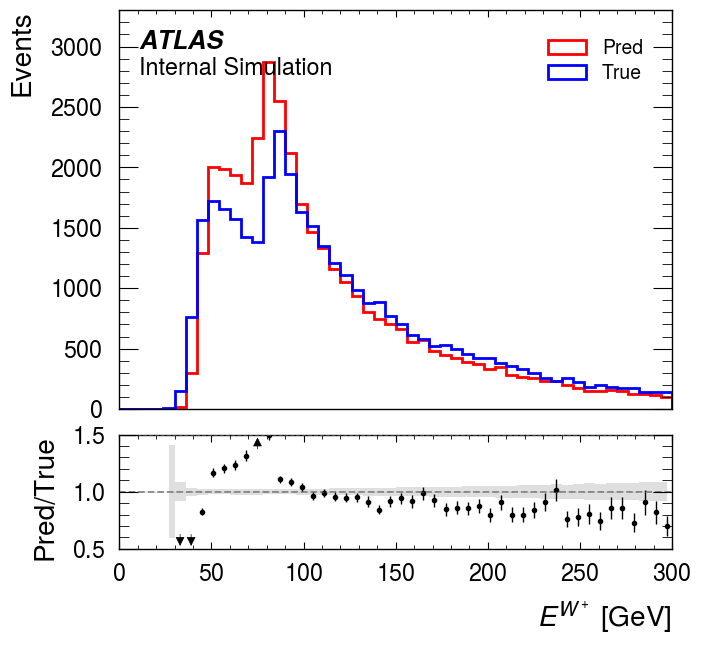

Rel err < 20%: 57.43 %


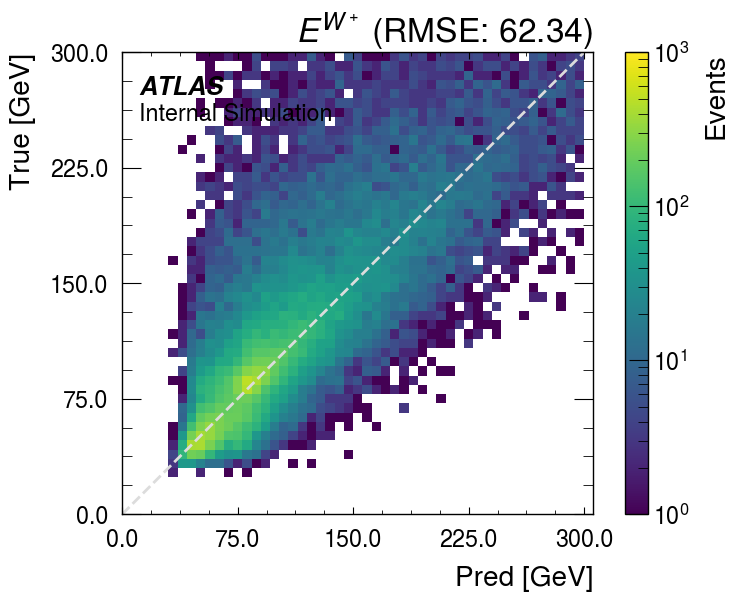

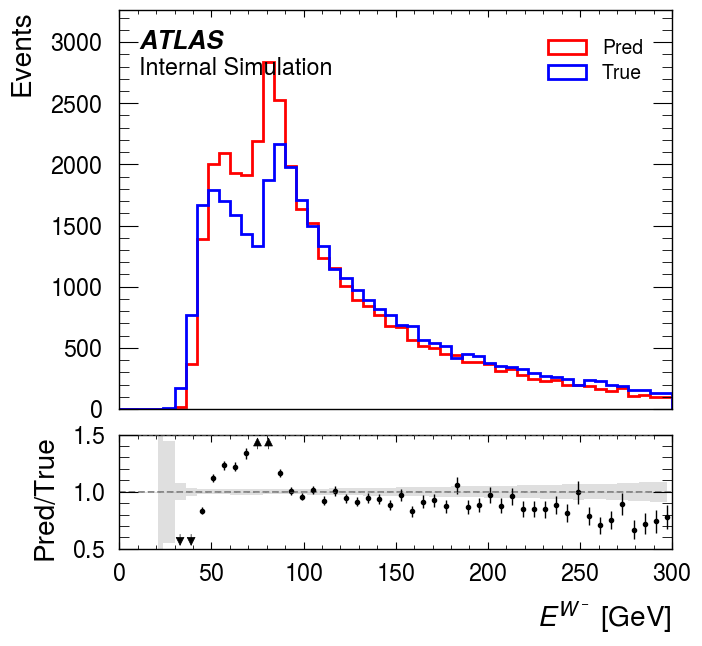

Rel err < 20%: 57.54 %


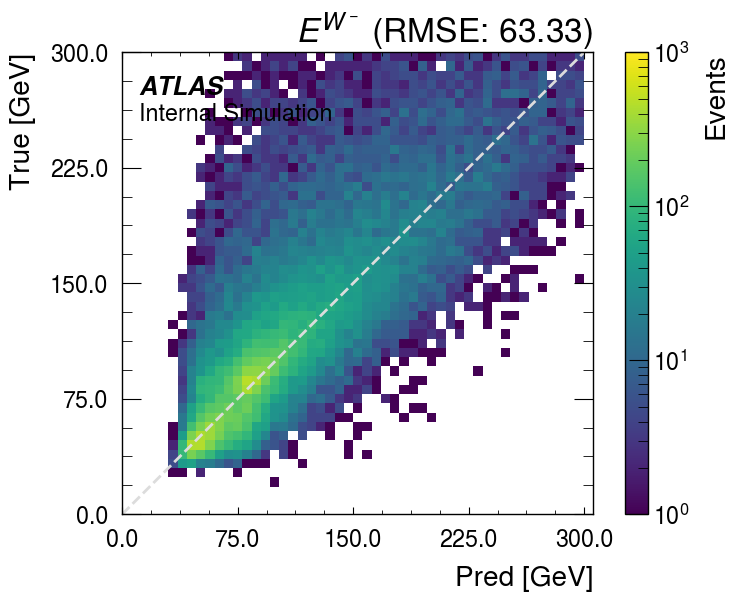

In [10]:
bins = np.linspace(0, 300, 51)
plot_1d_hist(pred_w0_energy, true_w0_energy, bins_edges=bins, name=r"$E^{W^+}$")
plot_2d_hist(pred_w0_energy, true_w0_energy, name=r"$E^{W^+}$", bins_edges=bins, log=True, color="black", vmax=1000)
plot_1d_hist(pred_w1_energy, true_w1_energy, bins_edges=bins, name=r"$E^{W^-}$")
plot_2d_hist(pred_w1_energy, true_w1_energy, name=r"$E^{W^-}$", bins_edges=bins, log=True, color="black", vmax=1000)

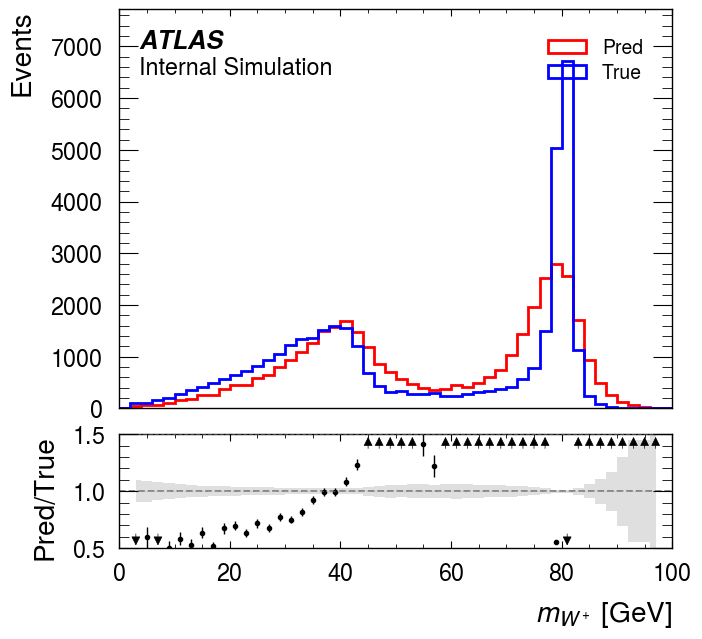

Rel err < 20%: 54.50 %


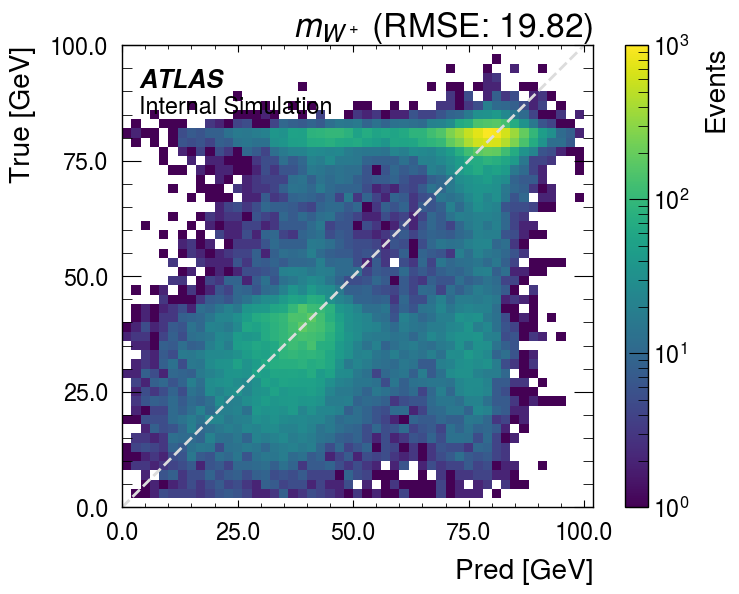

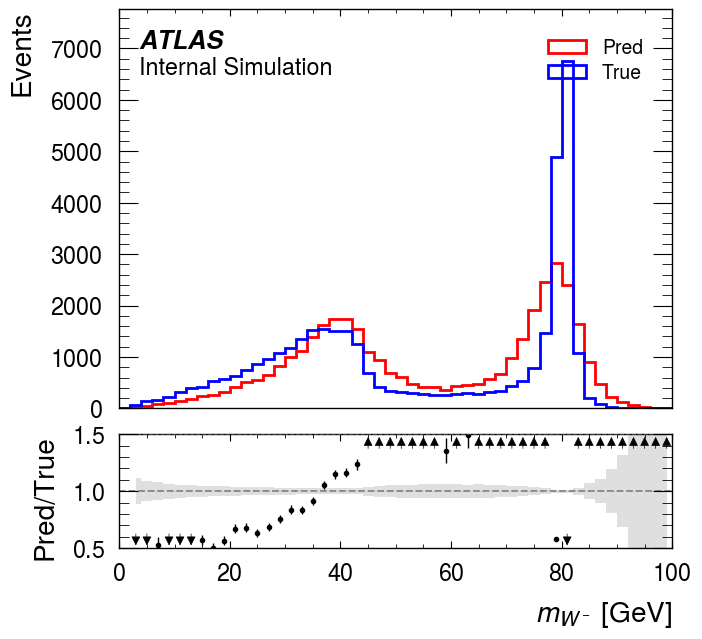

Rel err < 20%: 54.10 %


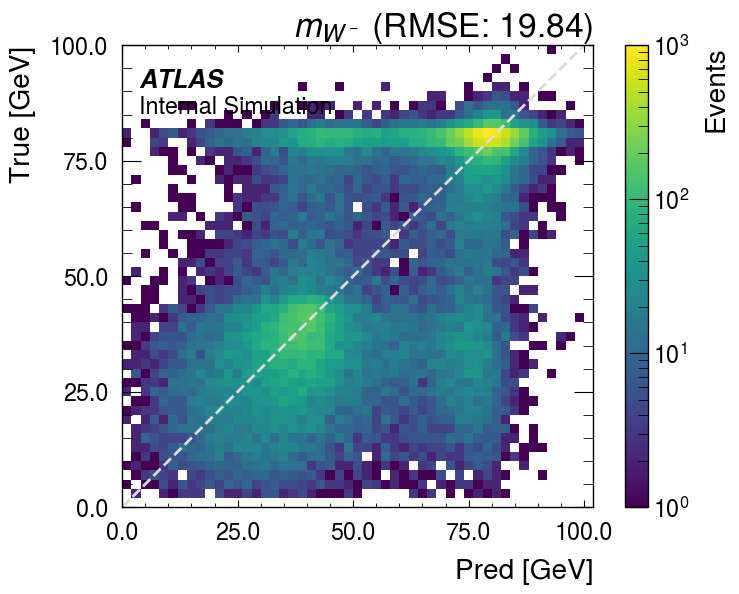

In [11]:
bins = np.linspace(0, 100, 51)
pred_w0_mass = safe_mass(pred_w0_mass_2)
pred_w1_mass = safe_mass(pred_w1_mass_2)
true_w0_mass = safe_mass(true_w0_mass_2)
true_w1_mass = safe_mass(true_w1_mass_2)

plot_1d_hist(pred_w0_mass, true_w0_mass, bins_edges=bins, name=r"$m_{W^+}$", unit="GeV")
plot_2d_hist(pred_w0_mass, true_w0_mass, name=r"$m_{W^+}$", bins_edges=bins, log=True, unit="GeV", vmax=1000)
plot_1d_hist(pred_w1_mass, true_w1_mass, bins_edges=bins, name=r"$m_{W^-}$", unit="GeV")
plot_2d_hist(pred_w1_mass, true_w1_mass, name=r"$m_{W^-}$", bins_edges=bins, log=True, unit="GeV", vmax=1000)


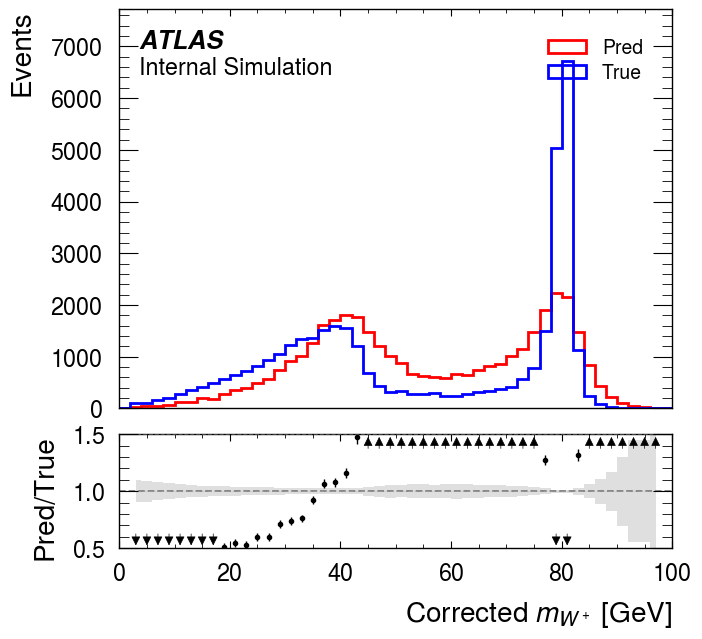

Rel err < 20%: 61.84 %


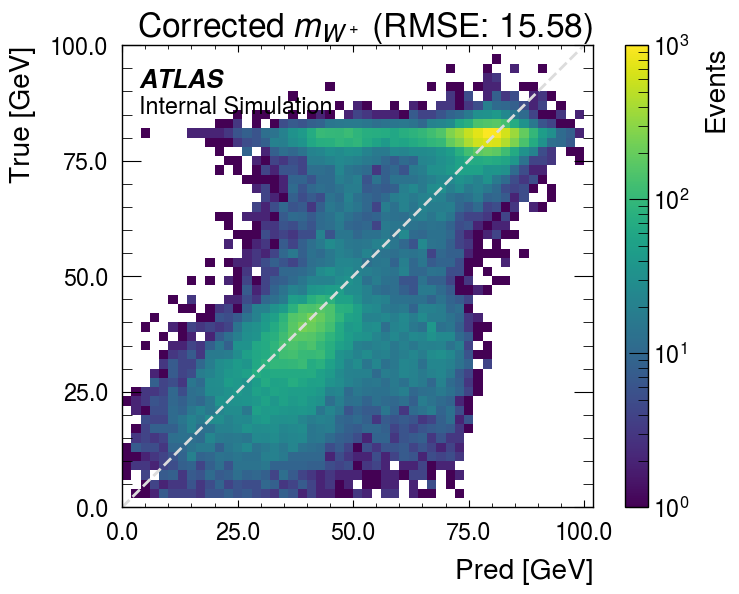

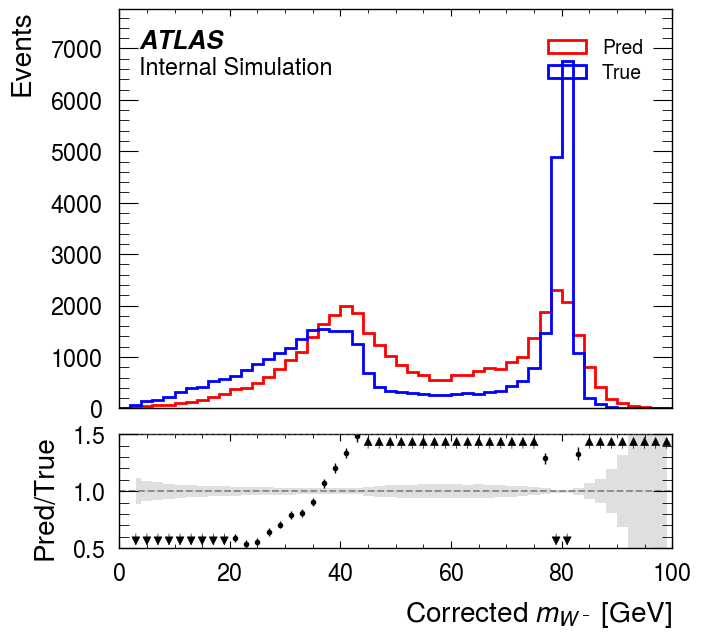

Rel err < 20%: 61.32 %


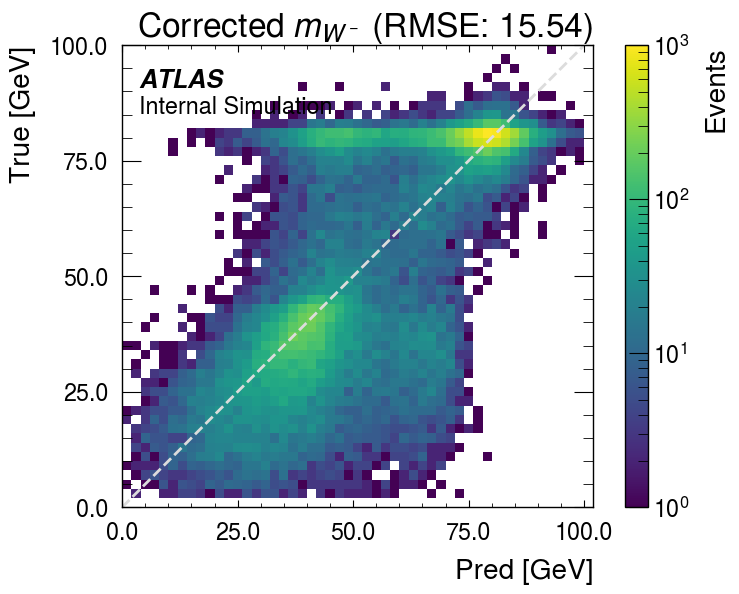

In [12]:
bins = np.linspace(0, 100, 51)

# W0: infer the neutrino from the predicted W and test the swapped lepton.
diff_w0 = pred_w0_mass - true_w0_mass
pred_nu0_px = pred_w0_px - true_lep0_px
pred_nu0_py = pred_w0_py - true_lep0_py
pred_nu0_pz = pred_w0_pz - true_lep0_pz
pred_nu0_energy = pred_w0_energy - true_lep0_energy
pred_nu0_mass_2 = (
    pred_nu0_energy**2
    - (pred_nu0_px**2 + pred_nu0_py**2 + pred_nu0_pz**2)
)
pred_nu0_mass = safe_mass(pred_nu0_mass_2)

pred_w0_px_swap = pred_nu0_px + true_lep1_px
pred_w0_py_swap = pred_nu0_py + true_lep1_py
pred_w0_pz_swap = pred_nu0_pz + true_lep1_pz
pred_w0_energy_swap = pred_nu0_energy + true_lep1_energy
pred_w0_mass_swap = safe_mass(
    pred_w0_energy_swap**2
    - (pred_w0_px_swap**2 + pred_w0_py_swap**2 + pred_w0_pz_swap**2)
)
diff_w0_swap = pred_w0_mass_swap - true_w0_mass
corr_mask_w0 = np.abs(diff_w0_swap) < np.abs(diff_w0)
corr_pred_w0_px = np.where(corr_mask_w0, pred_w0_px_swap, pred_w0_px)
corr_pred_w0_py = np.where(corr_mask_w0, pred_w0_py_swap, pred_w0_py)
corr_pred_w0_pz = np.where(corr_mask_w0, pred_w0_pz_swap, pred_w0_pz)
corr_pred_w0_energy = np.where(corr_mask_w0, pred_w0_energy_swap, pred_w0_energy)
corr_pred_w0_p4 = np.stack([corr_pred_w0_px, corr_pred_w0_py, corr_pred_w0_pz, corr_pred_w0_energy], axis=1)
corr_pred_w0_mass = np.where(corr_mask_w0, pred_w0_mass_swap, pred_w0_mass)

# W1: mirror the same correction using the opposite lepton assignment.
diff_w1 = pred_w1_mass - true_w1_mass
pred_nu1_px = pred_w1_px - true_lep1_px
pred_nu1_py = pred_w1_py - true_lep1_py
pred_nu1_pz = pred_w1_pz - true_lep1_pz
pred_nu1_energy = pred_w1_energy - true_lep1_energy
pred_nu1_mass_2 = (
    pred_nu1_energy**2
    - (pred_nu1_px**2 + pred_nu1_py**2 + pred_nu1_pz**2)
)
pred_nu1_mass = safe_mass(pred_nu1_mass_2)

pred_w1_px_swap = pred_nu1_px + true_lep0_px
pred_w1_py_swap = pred_nu1_py + true_lep0_py
pred_w1_pz_swap = pred_nu1_pz + true_lep0_pz
pred_w1_energy_swap = pred_nu1_energy + true_lep0_energy
pred_w1_mass_swap = safe_mass(
    pred_w1_energy_swap**2
    - (pred_w1_px_swap**2 + pred_w1_py_swap**2 + pred_w1_pz_swap**2)
)
diff_w1_swap = pred_w1_mass_swap - true_w1_mass
corr_mask_w1 = np.abs(diff_w1_swap) < np.abs(diff_w1)
corr_pred_w1_px = np.where(corr_mask_w1, pred_w1_px_swap, pred_w1_px)
corr_pred_w1_py = np.where(corr_mask_w1, pred_w1_py_swap, pred_w1_py)
corr_pred_w1_pz = np.where(corr_mask_w1, pred_w1_pz_swap, pred_w1_pz)
corr_pred_w1_energy = np.where(corr_mask_w1, pred_w1_energy_swap, pred_w1_energy)
corr_pred_w1_p4 = np.stack([corr_pred_w1_px, corr_pred_w1_py, corr_pred_w1_pz, corr_pred_w1_energy], axis=1)
corr_pred_w1_mass = np.where(corr_mask_w1, pred_w1_mass_swap, pred_w1_mass)

# True neutrino masses for reference plots.
true_nu0_px = true_w0_px - true_lep0_px
true_nu0_py = true_w0_py - true_lep0_py
true_nu0_pz = true_w0_pz - true_lep0_pz
true_nu0_energy = true_w0_energy - true_lep0_energy
true_nu0_mass = safe_mass(
    true_nu0_energy**2
    - (true_nu0_px**2 + true_nu0_py**2 + true_nu0_pz**2)
)

true_nu1_px = true_w1_px - true_lep1_px
true_nu1_py = true_w1_py - true_lep1_py
true_nu1_pz = true_w1_pz - true_lep1_pz
true_nu1_energy = true_w1_energy - true_lep1_energy
true_nu1_mass = safe_mass(
    true_nu1_energy**2
    - (true_nu1_px**2 + true_nu1_py**2 + true_nu1_pz**2)
)

plot_1d_hist(corr_pred_w0_mass, true_w0_mass, bins_edges=bins, name=r"Corrected $m_{W^+}$", unit="GeV")
plot_2d_hist(corr_pred_w0_mass, true_w0_mass, name=r"Corrected $m_{W^+}$", bins_edges=bins, log=True, unit="GeV", vmax=1000)
plot_1d_hist(corr_pred_w1_mass, true_w1_mass, bins_edges=bins, name=r"Corrected $m_{W^-}$", unit="GeV")
plot_2d_hist(corr_pred_w1_mass, true_w1_mass, name=r"Corrected $m_{W^-}$", bins_edges=bins, log=True, unit="GeV", vmax=1000)


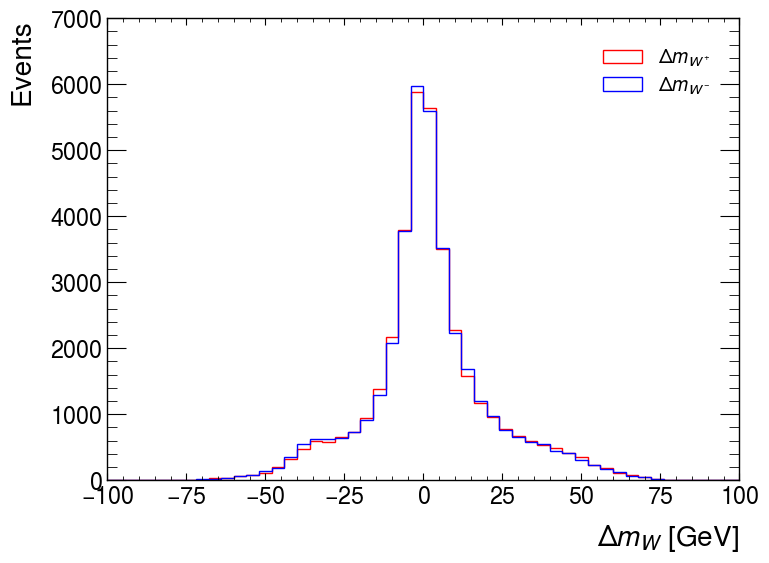

In [13]:
diff_mass_pos = pred_w0_mass - true_w0_mass
diff_mass_neg = pred_w1_mass - true_w1_mass
bins_edges = np.linspace(-100, 100, 51)
plt.hist(diff_mass_pos, bins=bins_edges, histtype='step', color='red',label=r"$\Delta m_{W^+}$")
plt.hist(diff_mass_neg, bins=bins_edges, histtype='step', color='blue',label=r"$\Delta m_{W^-}$")
plt.xlabel(r"$\Delta m_W$ [GeV]")
plt.ylabel("Events")
plt.legend()
plt.show()

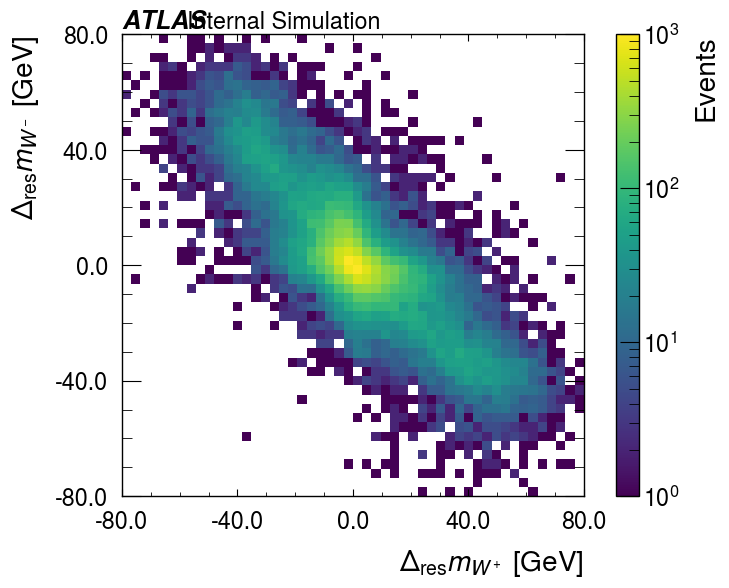

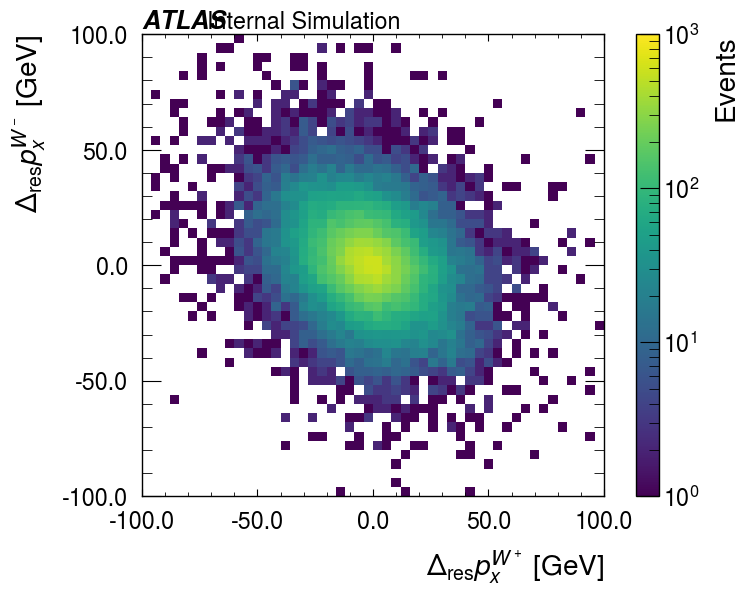

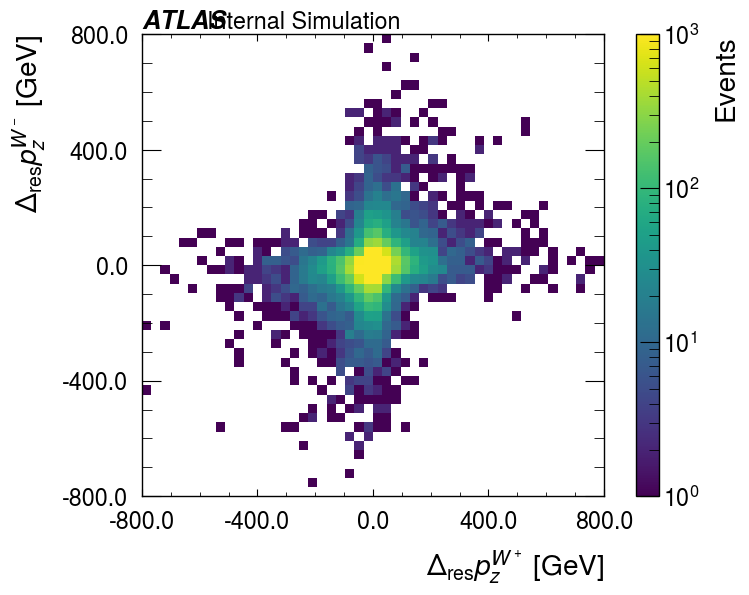

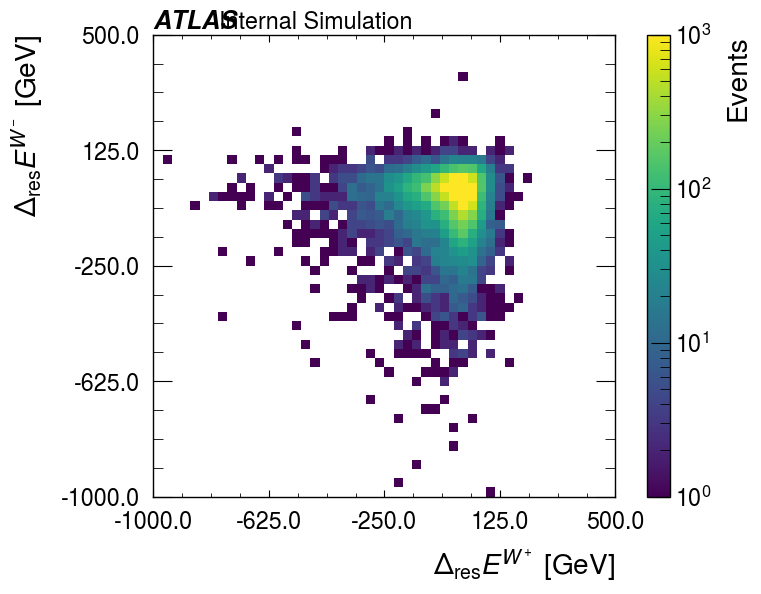

In [14]:
w0_mass_res = pred_w0_mass - true_w0_mass
w1_res = pred_w1_mass - true_w1_mass
plot_2d_res_hist(w0_mass_res, w1_res, name_pos=r"$m_{W^+}$", name_neg=r"$m_{W^-}$", bins_edges=np.linspace(-80, 80, 51), log=True, unit="GeV", color="black", vmax=1000)

w0_px_res = pred_w0_px - true_w0_px
w1_px_res = pred_w1_px - true_w1_px
plot_2d_res_hist(w0_px_res, w1_px_res, name_pos=r"$p_x^{W^+}$", name_neg=r"$p_x^{W^-}$", bins_edges=np.linspace(-100, 100, 51), log=True, unit="GeV", color="black", vmax=1000)

w0_pz_res = pred_w0_pz - true_w0_pz
w1_pz_res = pred_w1_pz - true_w1_pz
plot_2d_res_hist(w0_pz_res, w1_pz_res, name_pos=r"$p_z^{W^+}$", name_neg=r"$p_z^{W^-}$", bins_edges=np.linspace(-800, 800, 51), log=True, unit="GeV", color="black", vmax=1000)

w0_energy_res = pred_w0_energy - true_w0_energy
w1_energy_res = pred_w1_energy - true_w1_energy
plot_2d_res_hist(w0_energy_res, w1_energy_res, name_pos=r"$E^{W^+}$", name_neg=r"$E^{W^-}$", bins_edges=np.linspace(-1000, 500, 51), log=True, unit="GeV", color="black", vmax=1000)

In [15]:
def alpha_func(lep_on_p4, neu_on_p4, lep_off_p4, neu_off_p4):
    
    def _cal_mass(p4):
        return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)
    
    def _cal_norm(p4):
        return np.sqrt(p4[:, 0]**2 + p4[:, 1]**2 + p4[:, 2]**2)
    
    # dinu_p4 = neu_on_p4 + neu_off_p4
    # dinu_mass = _cal_mass(dinu_p4)
    dinu_lep_on_p4 = lep_on_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_on_mass = _cal_mass(dinu_lep_on_p4)
    dinu_lep_off_p4 = lep_off_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_off_mass = _cal_mass(dinu_lep_off_p4)
        
    alpha = np.where(
        dinu_lep_on_mass > dinu_lep_off_mass,
        _cal_norm(neu_on_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16),
        _cal_norm(neu_off_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16)
    )
    
    return alpha

# true
true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=-1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=-1)
true_lep0_p4 = np.stack([true_lep0_px, true_lep0_py, true_lep0_pz, true_lep0_energy], axis=-1)
true_lep1_p4 = np.stack([true_lep1_px, true_lep1_py, true_lep1_pz, true_lep1_energy], axis=-1)

# pred
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=-1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=-1)

w_mass_con = 80.379 # GeV
w_mass_con_2 = w_mass_con ** 2

true_0_on_mask = np.abs(true_w0_mass_2 - w_mass_con_2) < np.abs(true_w1_mass_2 - w_mass_con_2)
true_lep_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep0_p4, true_lep1_p4)
true_lep_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep1_p4, true_lep0_p4)
true_w_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w0_p4, true_w1_p4)
true_w_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w1_p4, true_w0_p4)
true_neu_on_p4 = true_w_on_p4 - true_lep_on_p4
true_neu_off_p4 = true_w_off_p4 - true_lep_off_p4

pred_0_on_mask = np.abs(pred_w0_mass_2 - w_mass_con_2) < np.abs(pred_w1_mass_2 - w_mass_con_2)
pred_w_on_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w0_p4, pred_w1_p4)
pred_w_off_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w1_p4, pred_w0_p4)
pred_neu_on_p4 = pred_w_on_p4 - true_lep_on_p4
pred_neu_off_p4 = pred_w_off_p4 - true_lep_off_p4

true_alpha = alpha_func(true_lep_on_p4, true_neu_on_p4, true_lep_off_p4, true_neu_off_p4)
pred_alpha = alpha_func(true_lep_on_p4, pred_neu_on_p4, true_lep_off_p4, pred_neu_off_p4)

/tmp/ipykernel_271478/4229498418.py:4: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)


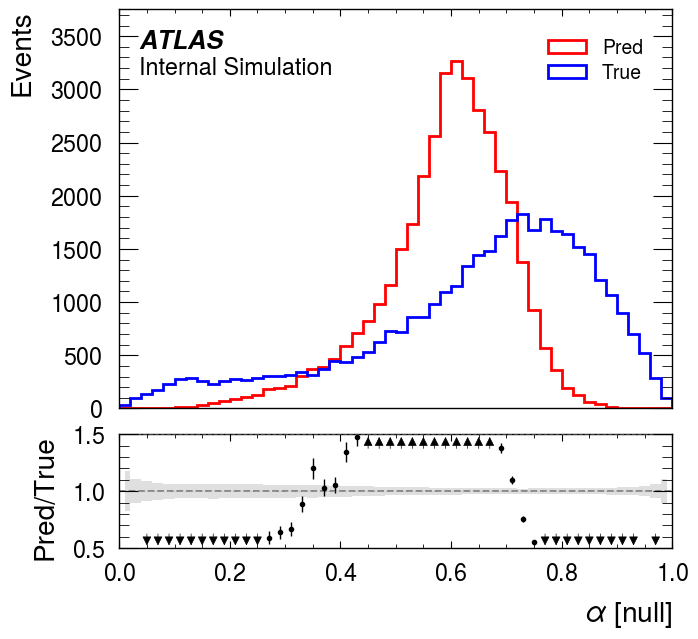

Rel err < 20%: 45.47 %


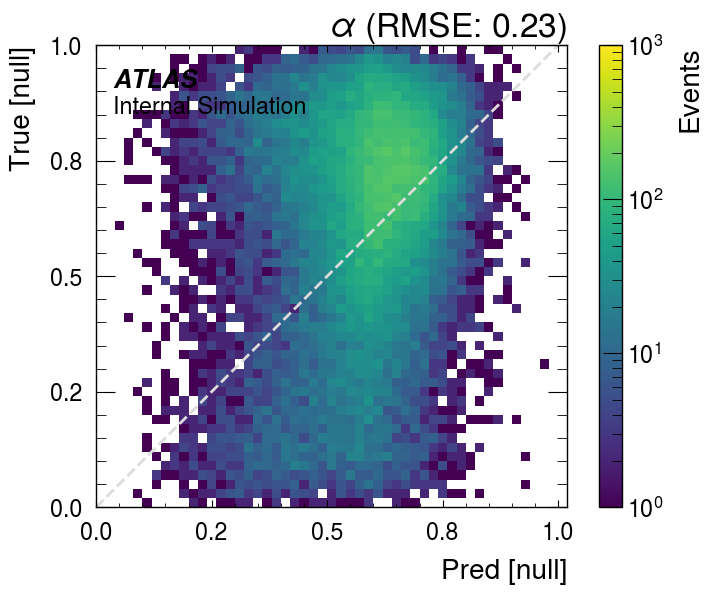

In [16]:
plot_1d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), unit="null")
plot_2d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), log=True, unit="null", color="black", vmax=1e3)

In [17]:
lep_p4 = np.concatenate([true_lep0_p4, true_lep1_p4], axis=1)
true_w_p4 = np.concatenate([true_w0_p4, true_w1_p4], axis=1)
pred_w_p4 = np.concatenate([pred_w0_p4, pred_w1_p4], axis=1)

def angular_features_like_training(lep_p4, true_w_p4, pred_w_p4, device):
    lep = torch.as_tensor(lep_p4, dtype=torch.float32, device=device)
    true_w = torch.as_tensor(true_w_p4, dtype=torch.float32, device=device)
    pred_w = torch.as_tensor(pred_w_p4, dtype=torch.float32, device=device)

    true_booster = TorchBooster(lep, true_w)
    pred_booster = TorchBooster(lep, pred_w)
    valid = true_booster.valid_rest_frame_mask() & pred_booster.valid_rest_frame_mask()

    true_ang = torch.stack(true_booster.lep_theta_phi_in_w_rest(), dim=-1)[valid]
    pred_ang = torch.stack(pred_booster.lep_theta_phi_in_w_rest(), dim=-1)[valid]
    return true_ang.cpu().numpy(), pred_ang.cpu().numpy(), valid.cpu().numpy()

true_ang, pred_ang, angular_valid = angular_features_like_training(lep_p4, true_w_p4, pred_w_p4, device)
print(f"Angular valid events: {angular_valid.sum()} / {len(angular_valid)}")

# true_l0_theta_phi = (true_ang[:, 0], true_ang[:, 1], true_ang[:, 2])
# true_l1_theta_phi = (true_ang[:, 3], true_ang[:, 4], true_ang[:, 5])
# pred_l0_theta_phi = (pred_ang[:, 0], pred_ang[:, 1], pred_ang[:, 2])
# pred_l1_theta_phi = (pred_ang[:, 3], pred_ang[:, 4], pred_ang[:, 5])
true_l0_theta_phi = (true_ang[:, 0], true_ang[:, 1])
true_l1_theta_phi = (true_ang[:, 2], true_ang[:, 3])
pred_l0_theta_phi = (pred_ang[:, 0], pred_ang[:, 1])
pred_l1_theta_phi = (pred_ang[:, 2], pred_ang[:, 3])


Angular valid events: 37669 / 37681


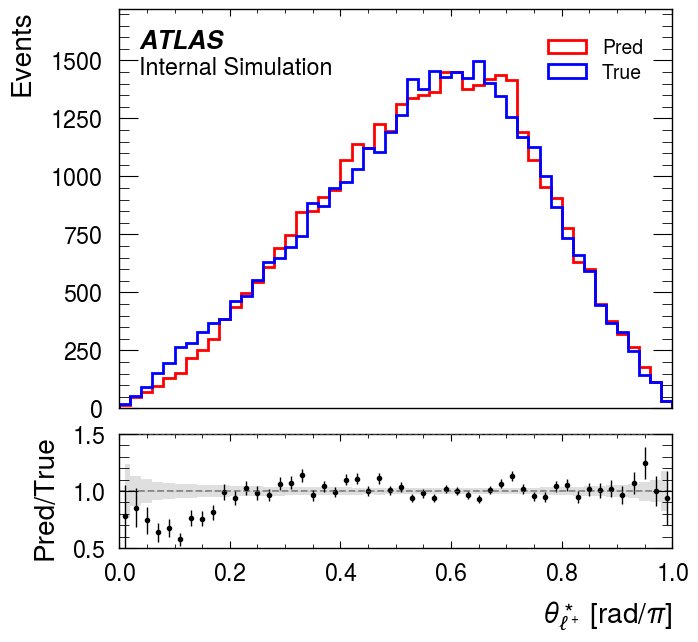

Rel err < 20%: 46.50 %


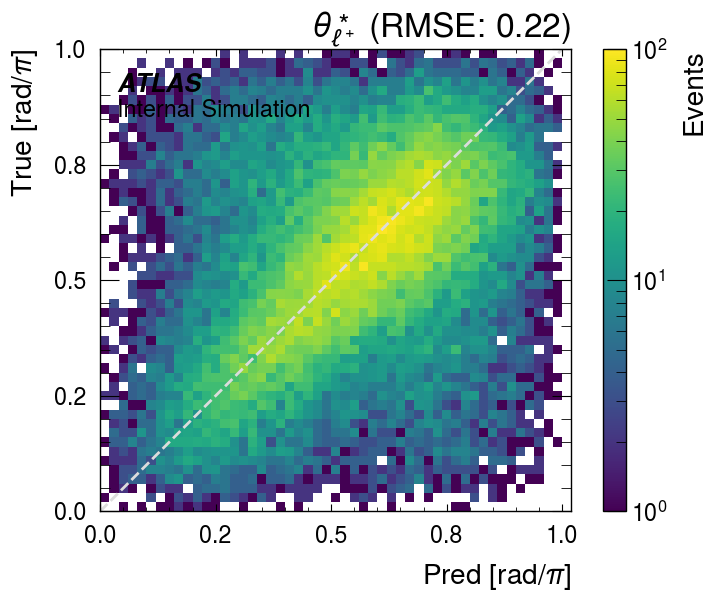

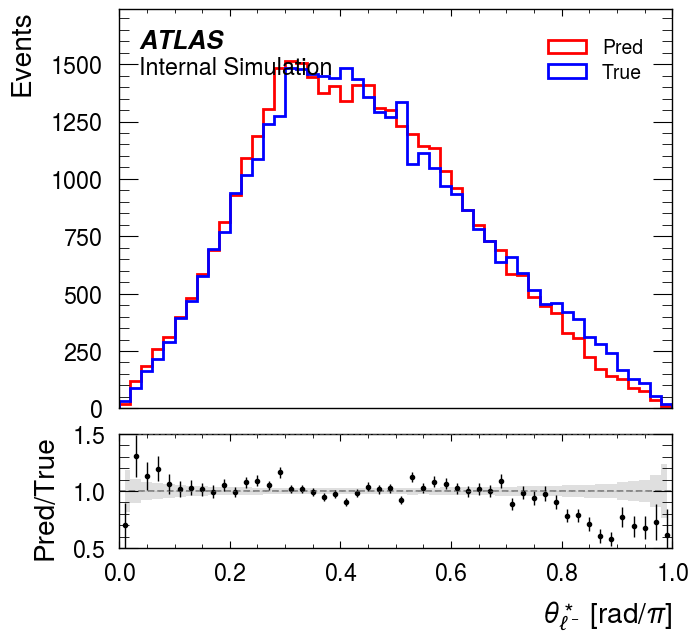

Rel err < 20%: 39.46 %


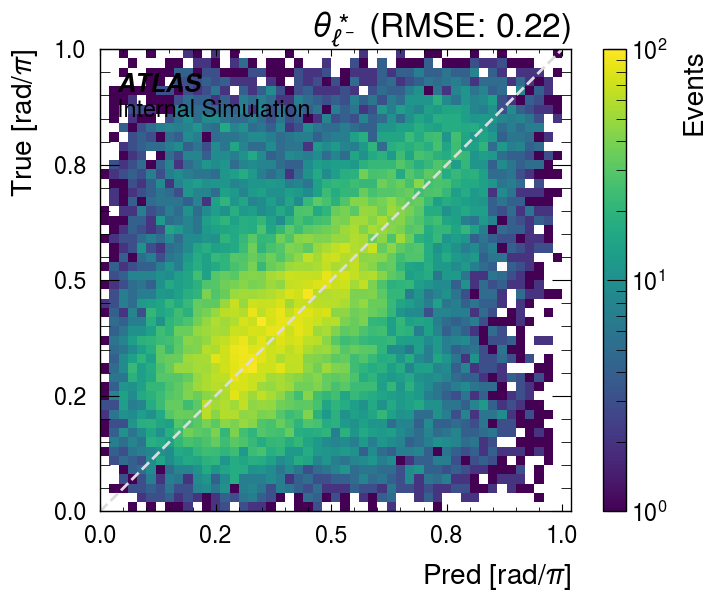

In [18]:
plot_1d_hist(pred_l0_theta_phi[0] / np.pi, true_l0_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l0_theta_phi[0] / np.pi, true_l0_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi[0] / np.pi, true_l1_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l1_theta_phi[0] / np.pi, true_l1_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

In [19]:
# plot_1d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\sin(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 51), unit="null")
# plot_2d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\sin(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 51), log=True, unit="null", color="black", vmax=1e2)
# plot_1d_hist(pred_l0_theta_phi[2], true_l0_theta_phi[2], r"$\cos(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 51), unit="null")
# plot_2d_hist(pred_l0_theta_phi[2], true_l0_theta_phi[2], r"$\cos(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 51), log=True, unit="null", color="black", vmax=1e2)

In [20]:
# plot_1d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\sin(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 51), unit="null")
# plot_2d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\sin(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 51), log=True, unit="null", color="black", vmax=1e2)
# plot_1d_hist(pred_l1_theta_phi[2], true_l1_theta_phi[2], r"$\cos(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 51), unit="null")
# plot_2d_hist(pred_l1_theta_phi[2], true_l1_theta_phi[2], r"$\cos(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 51), log=True, unit="null", color="black", vmax=1e2)

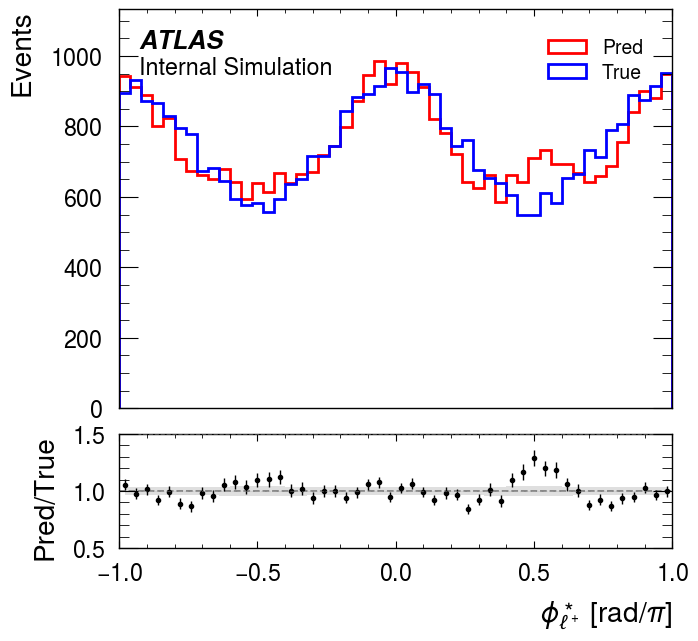

Rel err < 20%: 17.53 %


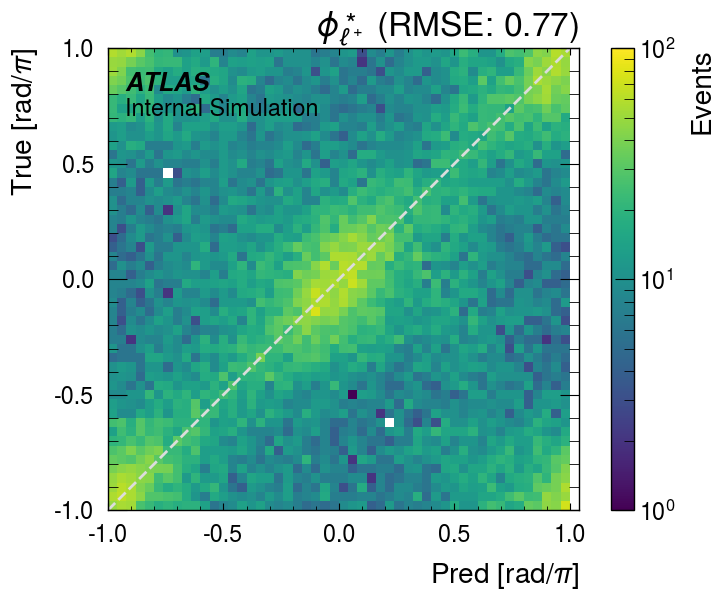

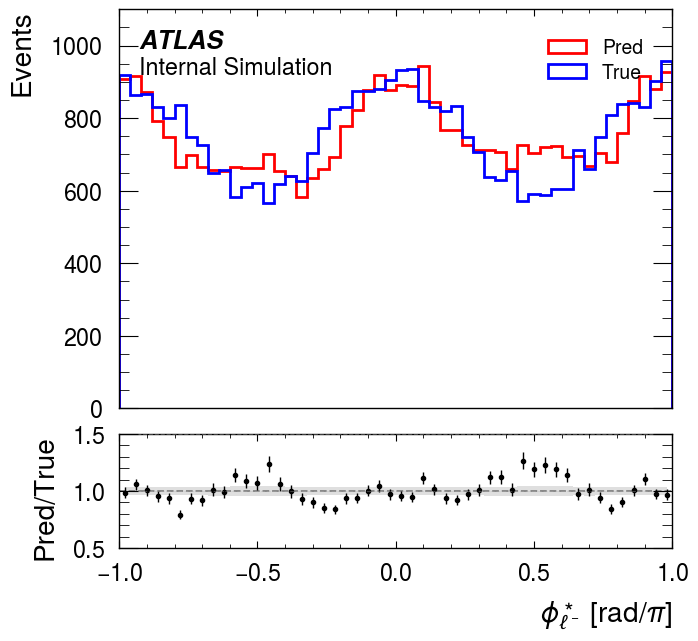

Rel err < 20%: 17.17 %


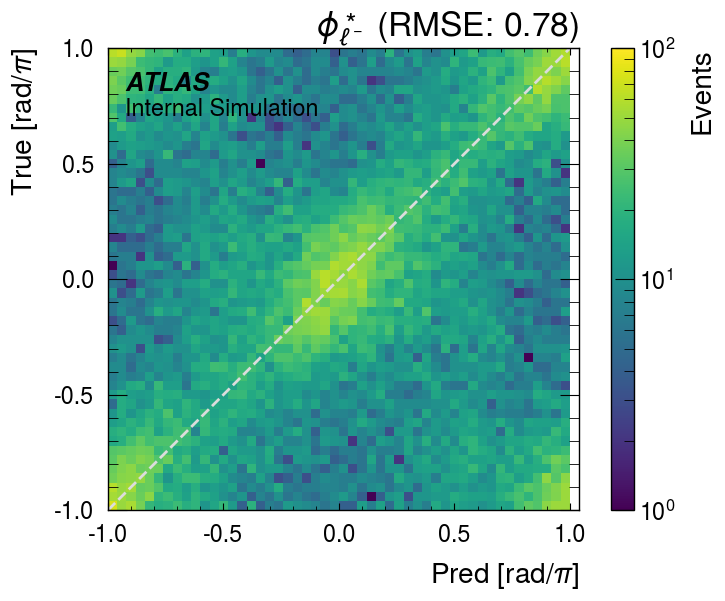

In [21]:
# true_l0_phi = np.arctan2(true_l0_theta_phi[1], true_l0_theta_phi[2])
# true_l1_phi = np.arctan2(true_l1_theta_phi[1], true_l1_theta_phi[2])
# pred_l0_phi = np.arctan2(pred_l0_theta_phi[1], pred_l0_theta_phi[2])
# pred_l1_phi = np.arctan2(pred_l1_theta_phi[1], pred_l1_theta_phi[2])
true_l0_phi = true_l0_theta_phi[1]
true_l1_phi = true_l1_theta_phi[1]
pred_l0_phi = pred_l0_theta_phi[1]
pred_l1_phi = pred_l1_theta_phi[1]

plot_1d_hist(pred_l0_phi / np.pi, true_l0_phi / np.pi, r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l0_phi / np.pi, true_l0_phi / np.pi, r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_phi / np.pi, true_l1_phi / np.pi, r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l1_phi / np.pi, true_l1_phi / np.pi, r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

Angular valid events: 37669 / 37681


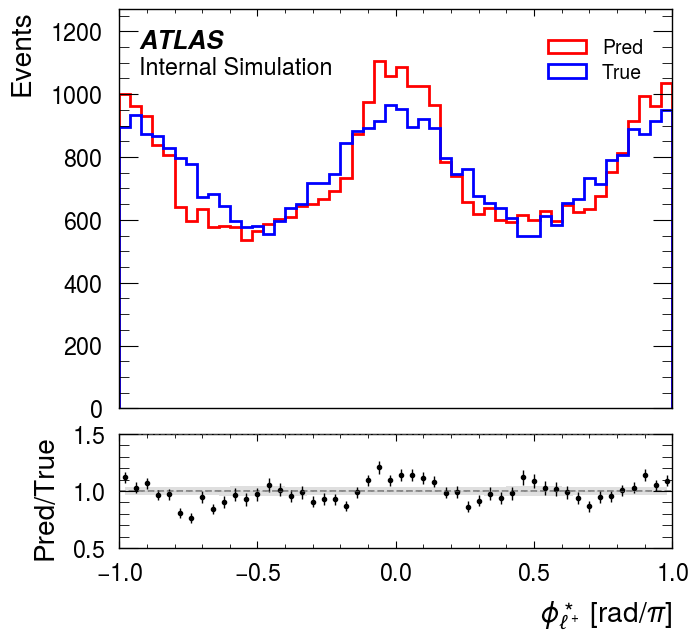

Rel err < 20%: 13.27 %


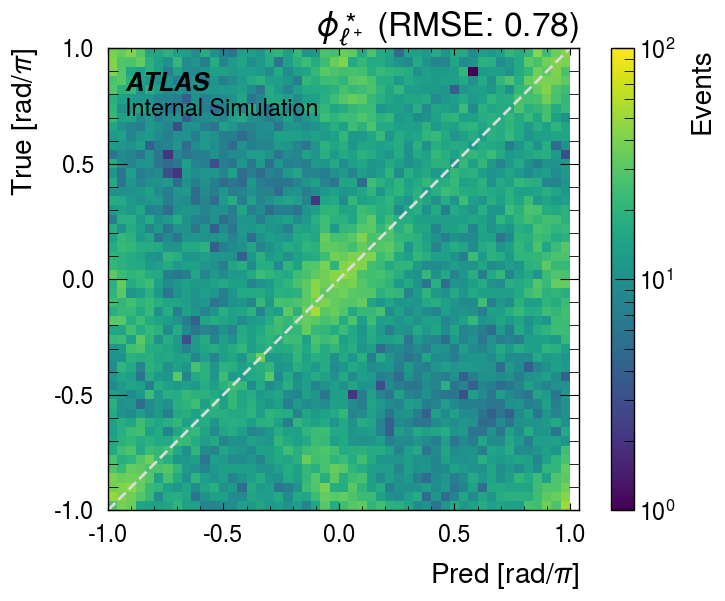

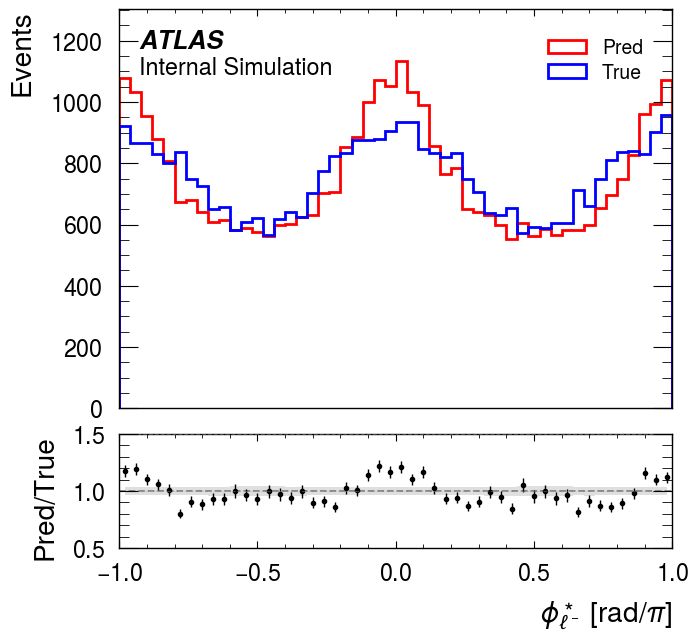

Rel err < 20%: 12.90 %


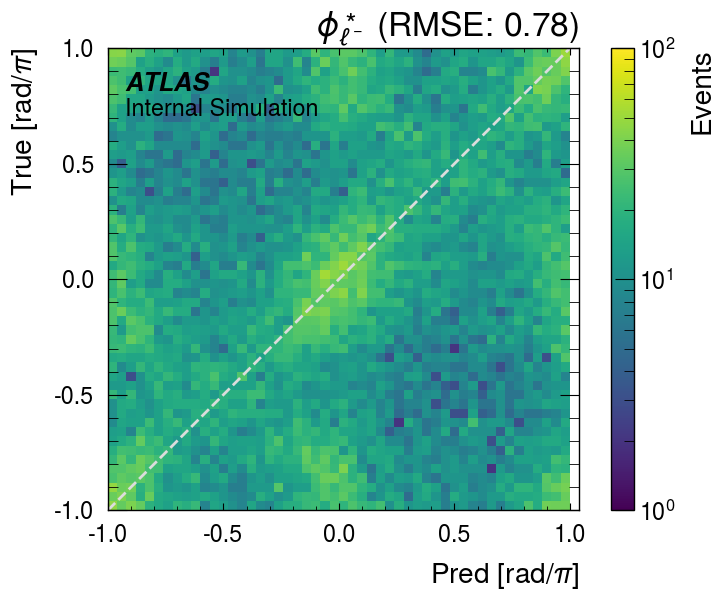

In [22]:
lep_p4 = np.concatenate([true_lep0_p4, true_lep1_p4], axis=1)
true_w_p4 = np.concatenate([true_w0_p4, true_w1_p4], axis=1)
pred_w_p4 = np.concatenate([corr_pred_w0_p4, corr_pred_w1_p4], axis=1)

def angular_features_like_training(lep_p4, true_w_p4, pred_w_p4, device):
    lep = torch.as_tensor(lep_p4, dtype=torch.float32, device=device)
    true_w = torch.as_tensor(true_w_p4, dtype=torch.float32, device=device)
    pred_w = torch.as_tensor(pred_w_p4, dtype=torch.float32, device=device)

    true_booster = TorchBooster(lep, true_w)
    pred_booster = TorchBooster(lep, pred_w)
    valid = true_booster.valid_rest_frame_mask() & pred_booster.valid_rest_frame_mask()

    true_ang = torch.stack(true_booster.lep_theta_phi_in_w_rest(), dim=-1)[valid]
    pred_ang = torch.stack(pred_booster.lep_theta_phi_in_w_rest(), dim=-1)[valid]
    return true_ang.cpu().numpy(), pred_ang.cpu().numpy(), valid.cpu().numpy()

true_ang, pred_ang, angular_valid = angular_features_like_training(lep_p4, true_w_p4, pred_w_p4, device)
print(f"Angular valid events: {angular_valid.sum()} / {len(angular_valid)}")

# true_l0_theta_phi = (true_ang[:, 0], true_ang[:, 1], true_ang[:, 2])
# true_l1_theta_phi = (true_ang[:, 3], true_ang[:, 4], true_ang[:, 5])
# pred_l0_theta_phi = (pred_ang[:, 0], pred_ang[:, 1], pred_ang[:, 2])
# pred_l1_theta_phi = (pred_ang[:, 3], pred_ang[:, 4], pred_ang[:, 5])
true_l0_theta_phi = (true_ang[:, 0], true_ang[:, 1])
true_l1_theta_phi = (true_ang[:, 2], true_ang[:, 3])
pred_l0_theta_phi = (pred_ang[:, 0], pred_ang[:, 1])
pred_l1_theta_phi = (pred_ang[:, 2], pred_ang[:, 3])
# true_l0_phi = np.arctan2(true_l0_theta_phi[1], true_l0_theta_phi[2])
# true_l1_phi = np.arctan2(true_l1_theta_phi[1], true_l1_theta_phi[2])
# pred_l0_phi = np.arctan2(pred_l0_theta_phi[1], pred_l0_theta_phi[2])
# pred_l1_phi = np.arctan2(pred_l1_theta_phi[1], pred_l1_theta_phi[2])
true_l0_phi = true_l0_theta_phi[1]
true_l1_phi = true_l1_theta_phi[1]
pred_l0_phi = pred_l0_theta_phi[1]
pred_l1_phi = pred_l1_theta_phi[1]

plot_1d_hist(pred_l0_phi / np.pi, true_l0_phi / np.pi, r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l0_phi / np.pi, true_l0_phi / np.pi, r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_phi / np.pi, true_l1_phi / np.pi, r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l1_phi / np.pi, true_l1_phi / np.pi, r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)


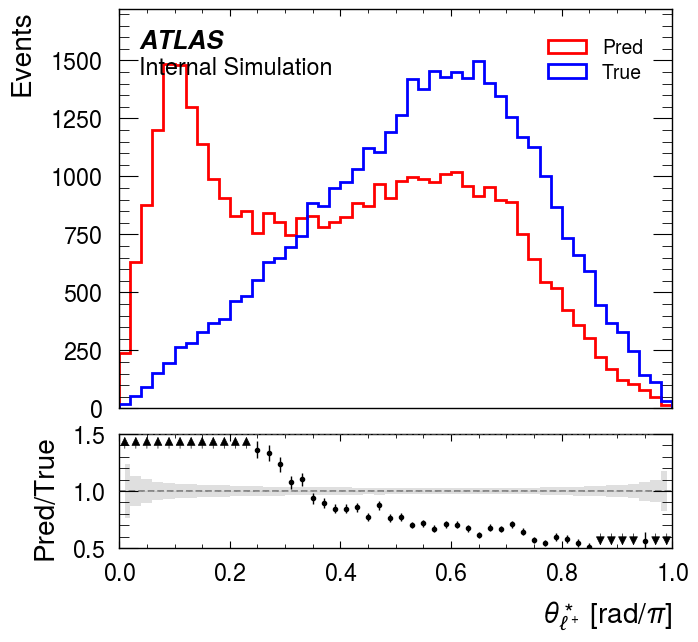

Rel err < 20%: 32.61 %


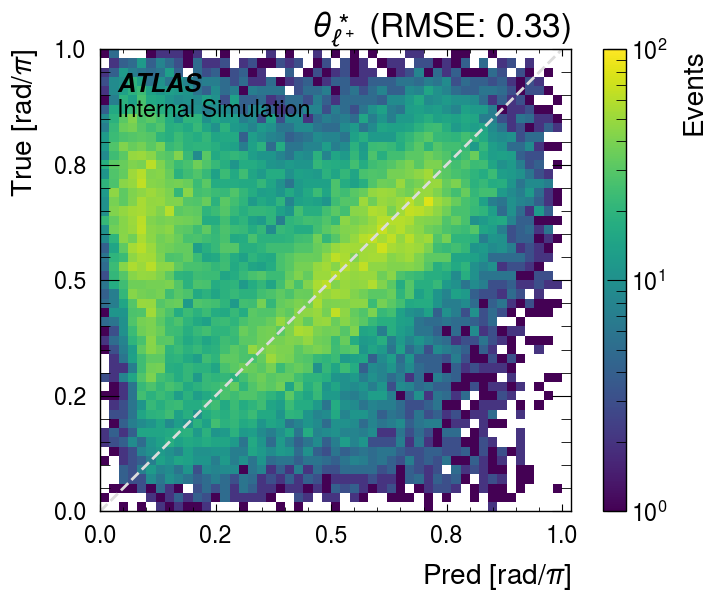

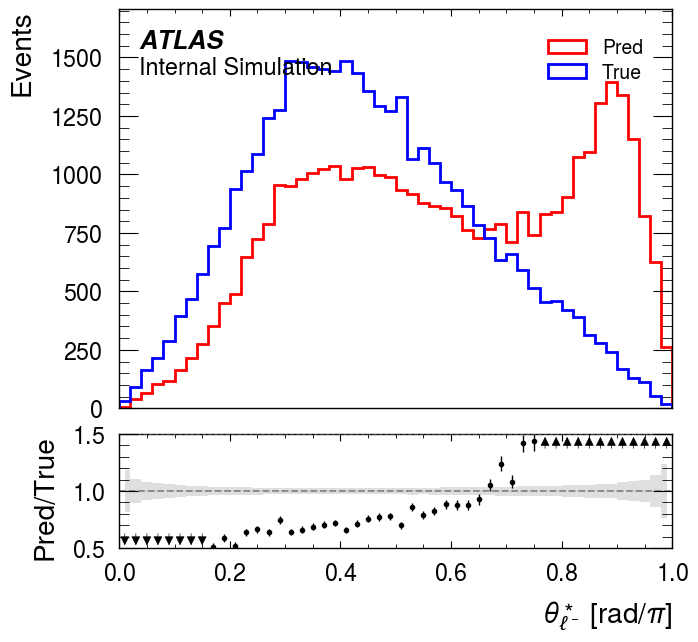

Rel err < 20%: 31.49 %


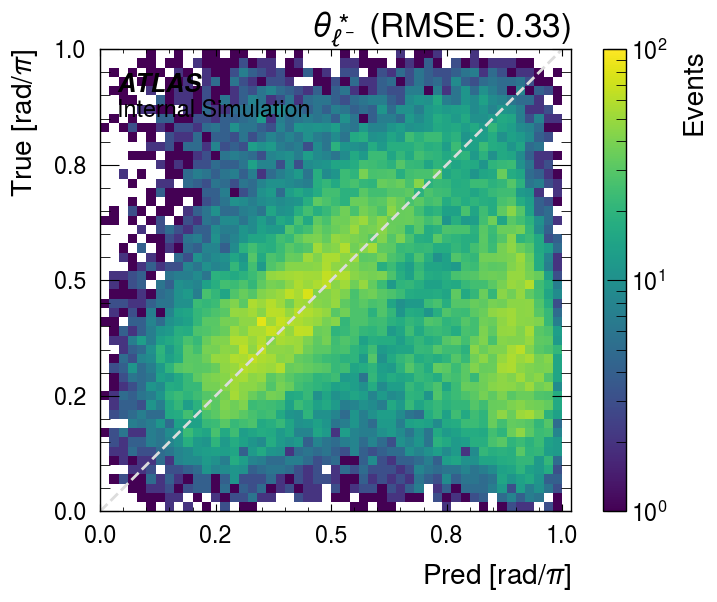

In [23]:
plot_1d_hist(pred_l0_theta_phi[0] / np.pi, true_l0_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l0_theta_phi[0] / np.pi, true_l0_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi[0] / np.pi, true_l1_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l1_theta_phi[0] / np.pi, true_l1_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

Found log directories: ['/root/work/ww-pcres/hww_pcres_regressor_nofold/logs/version_0']


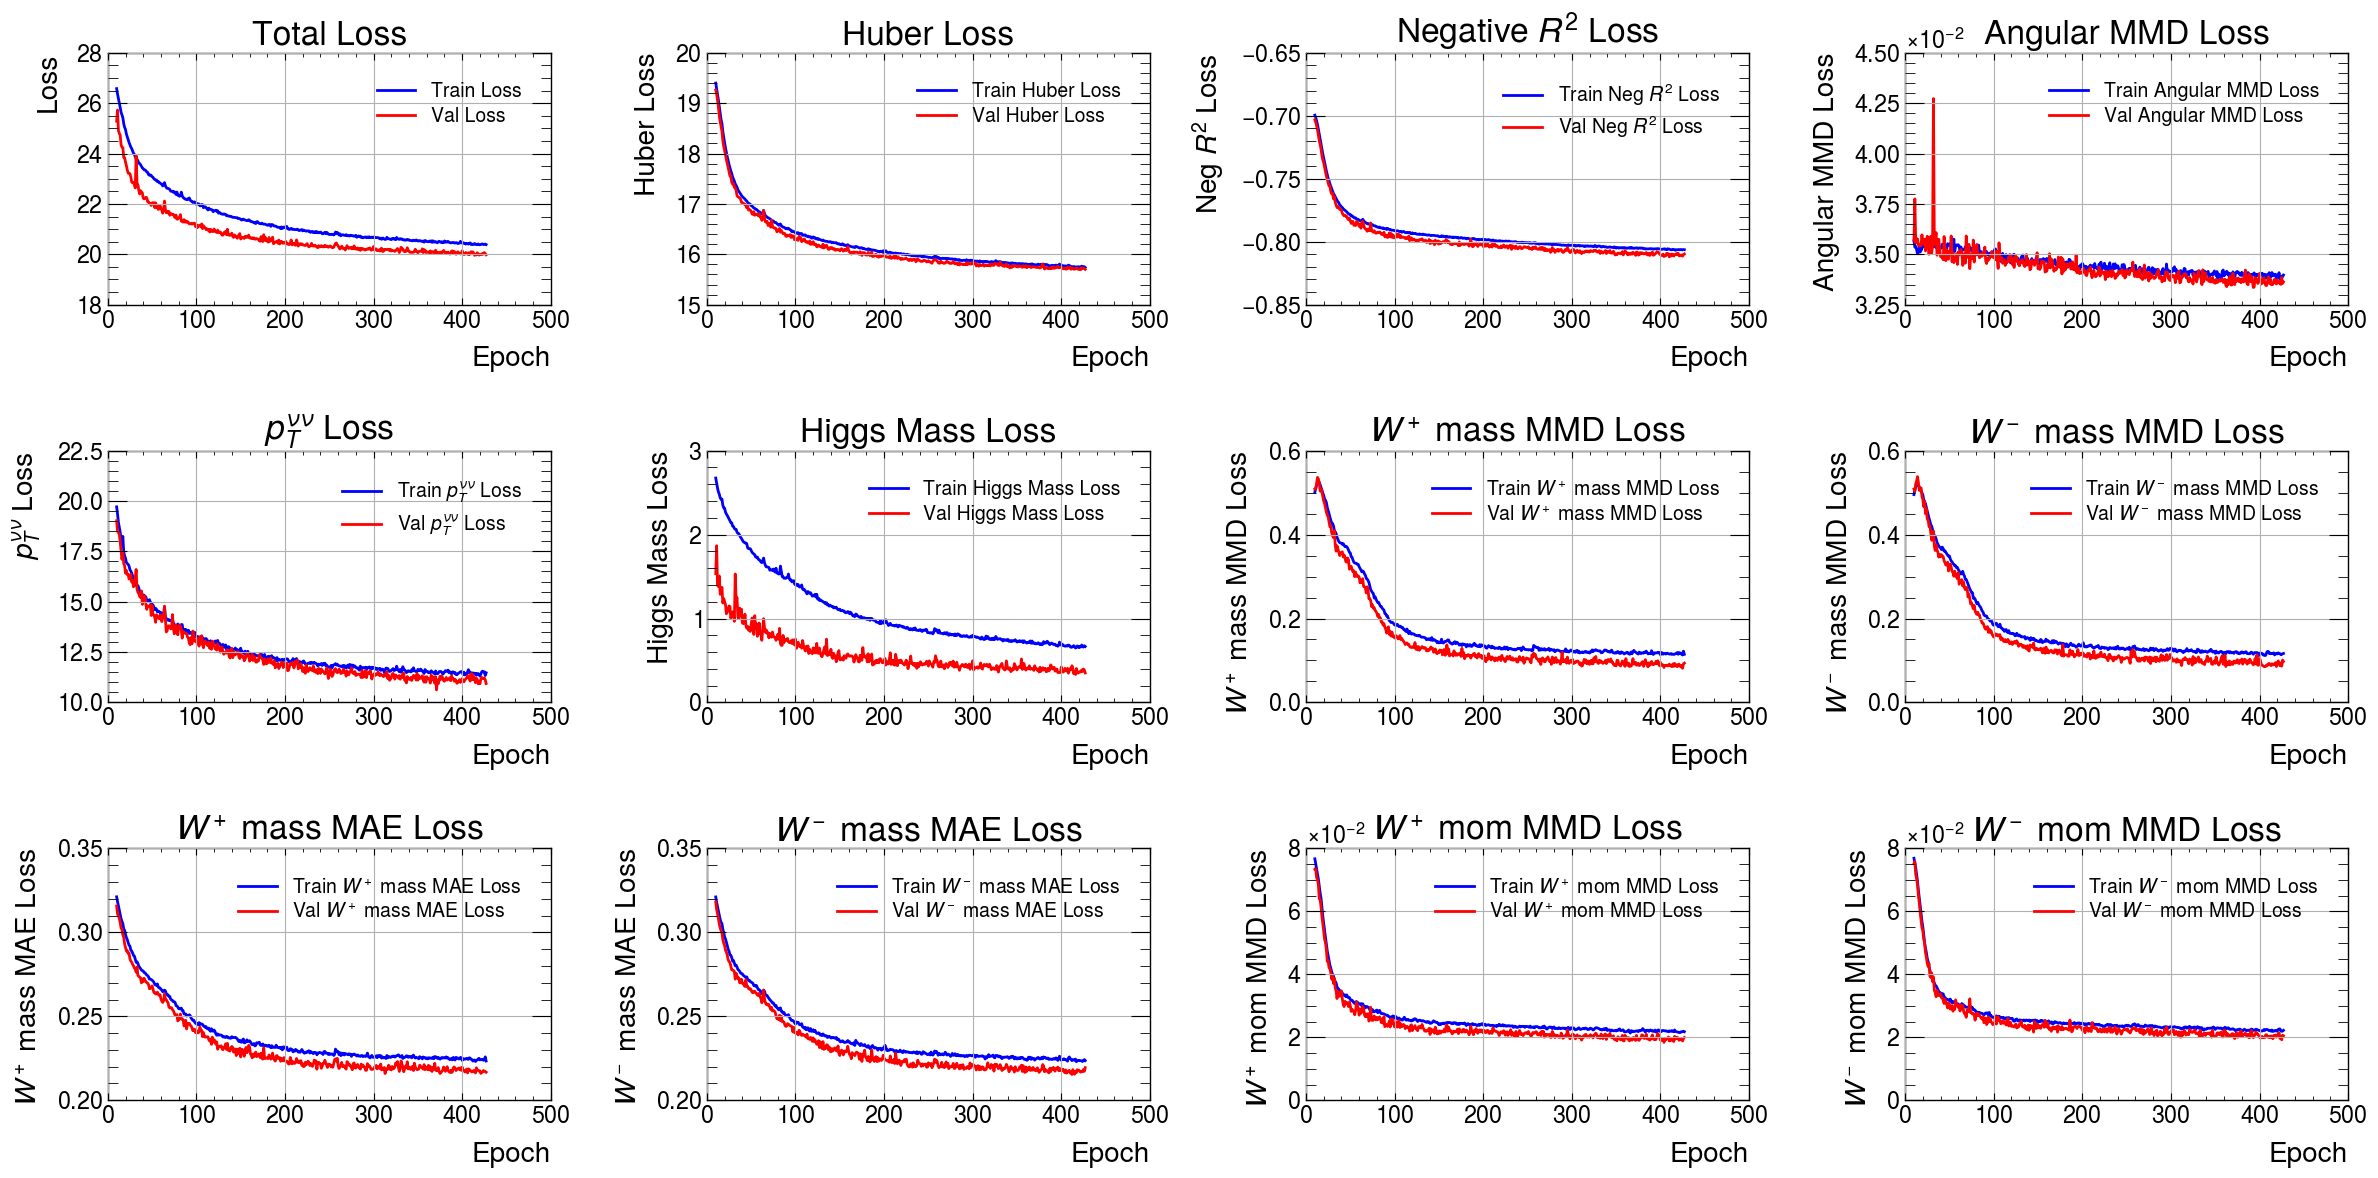

Final Training Losses (Epoch 427):
  Total Loss: 20.385700
  Huber Loss: 15.737502
  Negative $R^2$ Loss: -0.806354
  Angular MMD Loss: 0.033969
  $p^{\nu\nu}_T$ Loss: 11.469828
  Higgs Mass Loss: 0.666478
  $W^+$ mass MMD Loss: 0.114662
  $W^-$ mass MMD Loss: 0.116712
  $W^+$ mass MAE Loss: 0.223384
  $W^-$ mass MAE Loss: 0.223621
  $W^+$ mom MMD Loss: 0.021777
  $W^-$ mom MMD Loss: 0.022211
Final Validation Losses:
  Total Loss: 19.978878
  Huber Loss: 15.700588
  Negative $R^2$ Loss: -0.809763
  Angular MMD Loss: 0.033625
  $p^{\nu\nu}_T$ Loss: 10.938088
  Higgs Mass Loss: 0.351211
  $W^+$ mass MMD Loss: 0.093679
  $W^-$ mass MMD Loss: 0.097543
  $W^+$ mass MAE Loss: 0.216711
  $W^-$ mass MAE Loss: 0.219403
  $W^+$ mom MMD Loss: 0.019962
  $W^-$ mom MMD Loss: 0.020473


In [24]:
log_dirs = sorted((RUN_DIR / "logs").glob("version_*"))
print(f"Found log directories: {[str(path) for path in log_dirs]}")
if not log_dirs:
    print("No logs found.")
else:
    metrics_path = log_dirs[0] / "metrics.csv"
    if not metrics_path.exists():
        print(f"No metrics.csv found in {log_dirs[0]}")
    else:
        df = pd.read_csv(metrics_path)
        df_clean_train = df[df["loss"].notna()] if "loss" in df.columns else pd.DataFrame()
        df_clean_val = df[df["val_loss"].notna()] if "val_loss" in df.columns else pd.DataFrame()

        if df_clean_train.empty or df_clean_val.empty:
            print("Not enough training or validation records to visualize.")
        else:
            plot_configs = [
                ("loss", "val_loss", "Total Loss", "Loss"),
                ("huber_loss", "val_huber_loss", "Huber Loss", "Huber Loss"),
                ("neg_r2_loss", "val_neg_r2_loss", "Negative $R^2$ Loss", "Neg $R^2$ Loss"),
                ("angular_loss_mmd_loss", "val_angular_loss_mmd_loss", "Angular MMD Loss", "Angular MMD Loss"),
                ("dinu_pt_loss", "val_dinu_pt_loss", r"$p^{\nu\nu}_T$ Loss", r"$p^{\nu\nu}_T$ Loss"),
                ("higgs_mass_loss", "val_higgs_mass_loss", "Higgs Mass Loss", "Higgs Mass Loss"),
                ("w_mass_mmd0_loss", "val_w_mass_mmd0_loss", "$W^+$ mass MMD Loss", "$W^+$ mass MMD Loss"),
                ("w_mass_mmd1_loss", "val_w_mass_mmd1_loss", "$W^-$ mass MMD Loss", "$W^-$ mass MMD Loss"),
                ("w0_mass_mae_loss", "val_w0_mass_mae_loss", "$W^+$ mass MAE Loss", "$W^+$ mass MAE Loss"),
                ("w1_mass_mae_loss", "val_w1_mass_mae_loss", "$W^-$ mass MAE Loss", "$W^-$ mass MAE Loss"),
                ("aux_mom_mmd0_loss", "val_aux_mom_mmd0_loss", "$W^+$ mom MMD Loss", "$W^+$ mom MMD Loss"),
                ("aux_mom_mmd1_loss", "val_aux_mom_mmd1_loss", "$W^-$ mom MMD Loss", "$W^-$ mom MMD Loss"),
            ]
            available_configs = [
                item for item in plot_configs
                if item[0] in df_clean_train.columns and item[1] in df_clean_val.columns
            ]

            ncols = 4
            nrows = int(np.ceil(len(available_configs) / ncols))
            fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
            axes = np.atleast_1d(axes).flatten()

            skip = min(10, max(0, len(df_clean_train) - 1))
            epochs_train = df_clean_train["epoch"].iloc[skip:]
            epochs_val = df_clean_val["epoch"].iloc[skip:]

            for ax, (train_col, val_col, title, ylabel) in zip(axes, available_configs):
                ax.plot(epochs_train, df_clean_train[train_col].iloc[skip:], label=f"Train {ylabel}", color="blue")
                ax.plot(epochs_val, df_clean_val[val_col].iloc[skip:], label=f"Val {ylabel}", color="red")
                ax.set_xlabel("Epoch")
                ax.set_ylabel(ylabel)
                ax.set_title(title)
                ax.legend()
                ax.grid(True)

            for ax in axes[len(available_configs):]:
                ax.set_visible(False)

            plt.tight_layout()
            plt.show()

            last_epoch = df_clean_train["epoch"].iloc[-1]
            print(f"Final Training Losses (Epoch {last_epoch}):")
            for train_col, _, title, _ in available_configs:
                print(f"  {title}: {df_clean_train[train_col].iloc[-1]:.6f}")

            print("Final Validation Losses:")
            for _, val_col, title, _ in available_configs:
                print(f"  {title}: {df_clean_val[val_col].iloc[-1]:.6f}")


In [25]:
# import shap
# import numpy as np
# import matplotlib as mpl
# from matplotlib import pyplot as plt

# mpl.rcParams.update(mpl.rcParamsDefault)

# # Feature order follows load_data.py train_obj construction.
# feature_names = [
#     "lep+ px", "lep+ py", "lep+ pz", "lep+ energy",
#     "lep- px", "lep- py", "lep- pz", "lep- energy",
#     "jet1 px", "jet1 py", "jet1 pz", "jet1 energy",
#     "jet2 px", "jet2 py", "jet2 pz", "jet2 energy",
#     "MET px", "MET py",
#     "m_ll", "dilepton pt", "MET pt", "delta eta ll",
#     "delta phi ll-MET", "delta phi lep+-MET",
#     "delta phi lep--MET", "delta phi ll",
# ]

# output_names = [
#     "W+ px", "W+ py", "W+ pz", "W+ log energy",
#     "W- px", "W- py", "W- pz", "W- log energy",
# ]

# background_sample = torch.tensor(train_features[0:256]).float().to(device)
# samples_to_explain = torch.tensor(train_features[512:512+1024]).float().to(device)
# x_explain = samples_to_explain.detach().cpu().numpy()

# if len(feature_names) != x_explain.shape[1]:
#     raise ValueError(f"Expected {len(feature_names)} features, got {x_explain.shape[1]}")

# explainer = shap.GradientExplainer(model, background_sample)
# shap_values = explainer.shap_values(samples_to_explain, nsamples=200)

# if isinstance(shap_values, list):
#     shap_values = np.stack(shap_values, axis=-1)

# importance_by_output = np.abs(shap_values).mean(axis=0)
# overall_importance = importance_by_output.mean(axis=1)
# top_overall = np.argsort(overall_importance)[::-1][:20]

# plt.figure(figsize=(9, 7))
# plt.barh(
#     [feature_names[idx] for idx in top_overall[::-1]],
#     overall_importance[top_overall[::-1]],
# )
# plt.xlabel("Mean |SHAP value| across outputs")
# plt.title("Overall SHAP Feature Importance", fontsize=15)
# plt.tight_layout()
# plt.show()

# heatmap_features = top_overall[::-1]
# plt.figure(figsize=(10, 8))
# plt.imshow(importance_by_output[heatmap_features], aspect="auto", cmap="viridis")
# plt.colorbar(label="Mean |SHAP value|")
# plt.yticks(range(len(heatmap_features)), [feature_names[idx] for idx in heatmap_features])
# plt.xticks(
#     range(min(len(output_names), importance_by_output.shape[1])),
#     output_names[:importance_by_output.shape[1]],
#     rotation=45,
#     ha="right",
# )
# plt.title("SHAP Importance by Feature and Output", fontsize=15)
# plt.tight_layout()
# plt.show()

# for i in range(shap_values.shape[-1]):
#     values = shap_values[:, :, i]
#     importance = importance_by_output[:, i]
#     top = np.argsort(importance)[::-1][:15]
#     output_label = output_names[i] if i < len(output_names) else f"output {i}"

#     print(f"Top features for {output_label}:")
#     for rank, idx in enumerate(top, start=1):
#         print(f"  {rank:2d}. {feature_names[idx]}: {importance[idx]:.6f}")

#     shap.summary_plot(
#         values,
#         x_explain,
#         feature_names=feature_names,
#         plot_type="bar",
#         max_display=15,
#         show=False,
#     )
#     plt.title(f"SHAP Feature Importance: {output_label}", fontsize=15)
#     plt.tight_layout()
#     plt.show()

#     shap.summary_plot(
#         values,
#         x_explain,
#         feature_names=feature_names,
#         plot_type="dot",
#         max_display=15,
#         show=False,
#     )
#     plt.title(f"SHAP Beeswarm: {output_label}", fontsize=15)
#     plt.tight_layout()
#     plt.show()